#### Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##### Data Cleaning and Analysis

In [2]:
df=pd.read_excel("E:\\ML\\BioActivity\\bioactivity_dataset_cleaned_new_v3.xlsx", sheet_name="Sheet1")
df.head(3)

,canonical_smiles,MW,LogP,NumHDonors,TPSA,NumRotatableBonds,bioactivity
0,O=C(CCCCCC(NC(=O)OCc1ccccc1)C(=O)Nc1cccc2cccnc...,464.522,3.9242,4,129.65,11,1
1,O=C(CCCCCC(C(=O)Nc1ccc2ncccc2c1)C(=O)Nc1ccc2nc...,485.544,4.4323,4,133.31,10,1
2,O=C(/C=C/c1cccc(C(C(=O)Nc2ccccc2)C(=O)Nc2ccccc...,415.449,3.5662,4,107.53,7,1


<!-- #### Data Cleaning -->

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5494 entries, 0 to 5493
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   canonical_smiles   5494 non-null   object 
 1   MW                 5494 non-null   float64
 2   LogP               5494 non-null   float64
 3   NumHDonors         5494 non-null   int64  
 4   TPSA               5494 non-null   float64
 5   NumRotatableBonds  5494 non-null   int64  
 6   bioactivity        5494 non-null   int64  
dtypes: float64(3), int64(3), object(1)
memory usage: 300.6+ KB


In [4]:
df.describe(include='all')

,canonical_smiles,MW,LogP,NumHDonors,TPSA,NumRotatableBonds,bioactivity
count,5494,5494.000000,5494.000000,5494.000000,5494.000000,5494.000000,5494.000000
unique,5470,NaN,NaN,NaN,NaN,NaN,NaN
top,O=C(CCCCCNC(=O)NC(=O)c1ccc(NS(=O)(=O)c2ccccc2)...,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,432.121366,3.677190,2.885329,102.017377,7.740444,0.787404
std,NaN,120.641617,1.469028,1.200443,37.486733,3.452148,0.409181
min,NaN,75.067000,-14.260700,0.000000,7.760000,0.000000,0.000000
25%,NaN,354.415250,2.693300,2.000000,78.510000,5.000000,1.000000
50%,NaN,415.432000,3.646200,3.000000,97.555000,7.000000,1.000000
75%,NaN,492.605000,4.552330,3.000000,119.480000,10.000000,1.000000


In [5]:
df.isnull().sum()

canonical_smiles     0
MW                   0
LogP                 0
NumHDonors           0
TPSA                 0
NumRotatableBonds    0
bioactivity          0
dtype: int64

<!-- #### Model Training -->

##### Data Prep.

In [6]:
df.columns

Index(['canonical_smiles', 'MW', 'LogP', 'NumHDonors', 'TPSA',
       'NumRotatableBonds', 'bioactivity'],
      dtype='object')

In [7]:
features_df = df.drop(['bioactivity'], axis=1)
target_df = df['bioactivity']

In [9]:
# fig, axes = plt.subplots(nrows=(len(numerical_cols) + 1) // 2, ncols=2, figsize=(14, 2.5 * ((len(numerical_cols) + 1) // 2)))
# axes = axes.flatten()

# for i, col in enumerate(numerical_cols):
#     axes[i].set_title(f'Distribution of {col} (KDE)')
#     sns.kdeplot(features_df[col], ax=axes[i], color='skyblue', fill=True, alpha=0.5)
#     axes[i].set_ylabel('Density')
#     axes[i].grid()
#     axes[i].set_xlabel(col)
# plt.tight_layout()
# plt.show()

In [8]:
from rdkit.Chem import rdFingerprintGenerator
from rdkit import Chem

features = []

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)
    
for idx, row in features_df.iterrows():
    # Convert SMILES to molecule object
    smile = row['canonical_smiles']
    mol = Chem.MolFromSmiles(smile)
    
    if mol:
        # Compute Morgan Fingerprints (ECFP)
        fingerprint = morgan_gen.GetFingerprint(mol)
        fingerprint_array = list(fingerprint)  # Convert to list
        
        # Collect features (fingerprint + descriptors)
        features.append(fingerprint_array + [row['MW'], row['LogP'], row['TPSA'], row['NumHDonors'],
                                                row['NumRotatableBonds']])

# Convert the features into a pandas DataFrame
X = pd.DataFrame(features)
X.shape

(5494, 1029)

In [9]:
len(features_df), len(target_df)

(5494, 5494)

In [10]:
X = X.set_index(features_df.index)
y = target_df.loc[features_df.index]

In [11]:
X.head(3)

,0,1,2,3,4,5,6,7,8,9,...,1019,1020,1021,1022,1023,1024,1025,1026,1027,1028
0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,464.522,3.9242,129.65,4,11
1,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,485.544,4.4323,133.31,4,10
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,415.449,3.5662,107.53,4,7


<!-- ##### Train Test Split -->

In [12]:

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
#X_val, X_test, y_val, y_test = train_test_split(X_train, y_train, test_size=0.5, stratify=y_train, random_state=42)
#X_train, y_train = SMOTE(random_state=42).fit_resample(X_train, y_train)

FP_COLS = list(range(1024)) # fingerprint bit indices
DESC_COLS = list(range(1024, X_train.shape[1])) # descriptor indices


# Feature scaling (needed for some base estimators)

scaler = StandardScaler()
X_train = X_train.to_numpy().copy()
X_test = X_test.to_numpy().copy()

X_train[:, DESC_COLS] = scaler.fit_transform(X_train[:, DESC_COLS])
X_test [:, DESC_COLS] = scaler.transform(X_test [:, DESC_COLS])

print(X_train.shape, y_train.shape)
#print(X_val.shape, y_val.shape)  
print(X_test.shape, y_test.shape)



(4395, 1029) (4395,)
(1099, 1029) (1099,)


In [59]:
# cols_to_plot = X_train.columns[1000:1008]
# fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 12))
# axes = axes.flatten()

# for i, col in enumerate(cols_to_plot):
#     sns.kdeplot(stat_x_train[col], ax=axes[i], color='skyblue', fill=True, alpha=0.5)
#     axes[i].set_title(f'Distribution of {col}')
#     axes[i].set_xlabel(col)
#     axes[i].set_ylabel('Density')
#     axes[i].grid()

# plt.tight_layout()
# plt.show()

In [13]:
print(y_train.value_counts())
print(y_test.value_counts())

bioactivity
1    3461
0     934
Name: count, dtype: int64
bioactivity
1    865
0    234
Name: count, dtype: int64


##### Statistical Testing

In [15]:
y_train[y_train==0].value_counts().sum()/y_train.value_counts().sum()

0.21248374512353707

Generating t-SNE visualization...


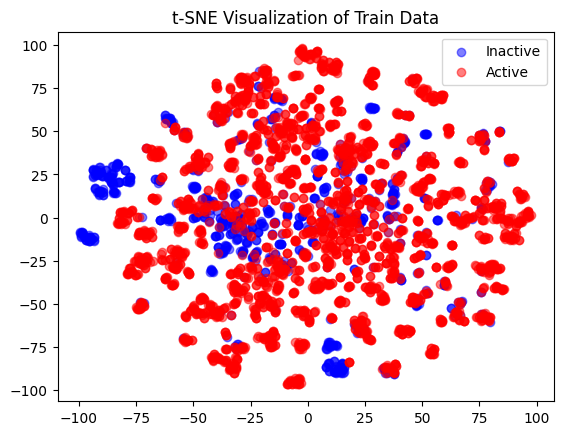

In [30]:
from sklearn.manifold import TSNE
print("Generating t-SNE visualization...")
# Use all features (embeddings + descriptors) for visualization
tsne = TSNE(n_components=2, perplexity=10, random_state=42)
X_tsne = tsne.fit_transform(X_train)
plt.scatter(X_tsne[y_train == 0, 0], X_tsne[y_train == 0, 1], label="Inactive", alpha=0.5, c='blue')
plt.scatter(X_tsne[y_train == 1, 0], X_tsne[y_train == 1, 1], label="Active", alpha=0.5, c='red')
plt.legend()
plt.title("t-SNE Visualization of Train Data")
plt.show()

e:\ML\BioActivity\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
e:\ML\BioActivity\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


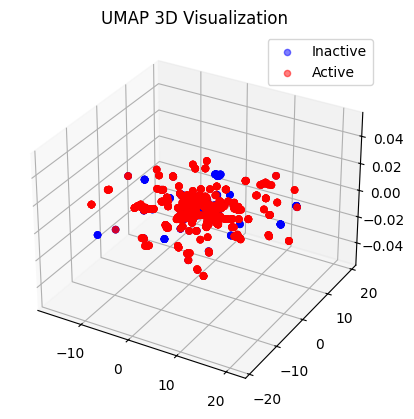

In [31]:
from umap.umap_ import UMAP
umap_model = UMAP(n_components=2, n_neighbors=7, min_dist=0.1, random_state=42)
X_umap = umap_model.fit_transform(X_train)
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_umap[y_train == 0, 0], X_umap[y_train == 0, 1],  c='blue', label="Inactive", alpha=0.5)
ax.scatter(X_umap[y_train == 1, 0], X_umap[y_train == 1, 1], c='red', label="Active", alpha=0.5)
ax.legend()
plt.title("UMAP 3D Visualization")
plt.show()

##### Utilities 

In [14]:
from sklearn.metrics import (
accuracy_score,
balanced_accuracy_score,
precision_score,
recall_score,
f1_score,
roc_auc_score,
matthews_corrcoef,
confusion_matrix,
average_precision_score,
cohen_kappa_score,
brier_score_loss
)
import os

PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

def plot_confusion_matrix(y_test, y_pred, model_name="model"):
    fig, ax = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title('Confusion Matrix')
    plt.tight_layout()
    os.makedirs(os.path.join(PLOTS_DIR, model_name), exist_ok=True)
    fig.savefig(os.path.join(PLOTS_DIR, model_name, f"{model_name}_confusion_matrix.png"), dpi=150)
    plt.show()

def plot_roc_curve(y_test, y_prob, model_name="model"):
    from sklearn.metrics import RocCurveDisplay
    fig, ax = plt.subplots(figsize=(6, 5))
    RocCurveDisplay.from_predictions(y_test, y_prob, ax=ax)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curve')
    plt.tight_layout()
    os.makedirs(os.path.join(PLOTS_DIR, model_name), exist_ok=True)
    fig.savefig(os.path.join(PLOTS_DIR, model_name, f"{model_name}_roc_curve.png"), dpi=150)
    plt.show()

def plot_auprc_curve(y_test, y_prob, model_name="model"):
    from sklearn.metrics import PrecisionRecallDisplay
    fig, ax = plt.subplots(figsize=(6, 5))
    PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=ax)
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title('AUPRC Curve')
    plt.tight_layout()
    os.makedirs(os.path.join(PLOTS_DIR, model_name), exist_ok=True)
    fig.savefig(os.path.join(PLOTS_DIR, model_name, f"{model_name}_auprc_curve.png"), dpi=150)
    plt.show()

def calc_metrics(final_model, model_name="model", best_thr=0.5):
    y_prob = final_model.predict_proba(X_test)[:, 1]  # Probabilities for positive class
    y_pred = (y_prob >= best_thr).astype(int)  # Binary predictions (threshold at best_thr)

    accuracy = accuracy_score(y_test, y_pred)
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    mcc = matthews_corrcoef(y_test, y_pred)
    auprc = average_precision_score(y_test, y_prob)
    kappa = cohen_kappa_score(y_test, y_pred, weights='quadratic')

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    npv = tn / (tn + fn) 
    specificity = tn / (tn + fp)
    sensitivity = recall  # same as recall
    informedness = sensitivity + specificity - 1

    dor = (tp * tn) / (fn * fp) if fp != 0 and fn != 0 else float('inf')

    brier = brier_score_loss(y_test, y_prob)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Balanced Acc.: {balanced_acc:.4f}")
    print(f"Cohen's Kappa: {kappa:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"AUPRC: {auprc:.4f}")
    print(f"MCC: {mcc:.4f}")
    print(f"NPV: {npv:.4f}")
    print(f"Specificity: {specificity:.4f}")
    print(f"Sensitivity: {sensitivity:.4f}")
    print("Informedness: {:.4f}".format(informedness))
    print(f"DOR: {dor:.4f}")
    print(f"Brier Score: {brier:.4f}")

    print("********************")
    print("Confusion Matrix:")
    plot_confusion_matrix(y_test, y_pred, model_name=model_name)
    print("ROC Curve:")
    plot_roc_curve(y_test, y_prob, model_name=model_name)
    print("AUPRC Curve:")
    plot_auprc_curve(y_test, y_prob, model_name=model_name)

In [15]:
from sklearn.metrics import log_loss
import numpy as np
import torch
import torch.nn as nn

# Focal Loss for Imbalanced Data (Test Set)

# Focal Loss implementation (binary classification)
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        BCE_loss = nn.BCEWithLogitsLoss(reduction='none')(inputs, targets)
        pt = torch.exp(-BCE_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * BCE_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        else:
            return focal_loss.sum()
        
def calc_loss(final_model):
    # Calculate log loss
    log_loss_value = log_loss(y_test, final_model.predict_proba(X_test))
    print("Log Loss(Test):", log_loss_value)

    log_loss_value = log_loss(y_train, final_model.predict_proba(X_train))
    print("Log Loss(Train):", log_loss_value)


    # Get predicted probabilities for the positive class
    y_proba = final_model.predict_proba(X_test)[:, 1]
    # Convert to logits (inverse of sigmoid)
    eps = 1e-8  # to avoid log(0)
    logits = np.log(y_proba / (1 - y_proba + eps) + eps)

    # Convert to torch tensors
    logits_tensor = torch.tensor(logits, dtype=torch.float32)
    targets_tensor = torch.tensor(y_test.values, dtype=torch.float32)

    # Calculate focal loss
    focal_loss_fn = FocalLoss(alpha=0.25, gamma=2.0)
    focal_loss_value = focal_loss_fn(logits_tensor, targets_tensor)
    print(f'Focal Loss (Test Set): {focal_loss_value.item():.4f}')

In [16]:
from pathlib import Path
import joblib
import json

Path("saved_model/ml_models").mkdir(parents=True, exist_ok=True)

def save_model(final_model, model_name, model_path="ml_models"):
    # Create the directory if it doesn't exist
    Path(f"saved_model/{model_path}").mkdir(parents=True, exist_ok=True)

    # Save the trained model (with compression)
    joblib.dump(final_model, f"saved_model/{model_path}/{model_name}.pkl", compress=3)

    print(f"Model saved to saved_model/{model_path}/")

In [20]:
def shap_plot(final_model):
    import shap

    # Create a SHAP explainer
    #explainer = shap.TreeExplainer(final_model, X_train)
    explainer = shap.Explainer(final_model, X_train)

    # Calculate SHAP values for the test set
    shap_values = explainer.shap_values(X_test)

    # Plot summary plot
    #shap.summary_plot(shap_values, X_test, plot_type="bar")

    #emb_idx = slice(0, 1000)  # e.g., 0:1000
    #desc_idx = slice(1000, 1004)

    #print("Desc Index: " ,desc_idx)

    #explainer = shap.TreeExplainer(final_model)
    #shap_values = explainer.shap_values(X_test)  # Shape: [n_samples, n_features]

    # Overall importance
    #mean_abs_shap = np.abs(shap_values).mean(0)
    #print("Embedding total importance:", mean_abs_shap[emb_idx].sum())
    #print("Descriptors importance:", mean_abs_shap[desc_idx])

    plt.figure(figsize=(8,8))
    shap.summary_plot(shap_values, X_test)  # Clean plot!



In [21]:
from lime.lime_tabular import LimeTabularExplainer

def lime_plot(final_model):
    def predict_proba_wrapper(X):
        return final_model.predict_proba(X)

    explainer = LimeTabularExplainer(
        X_train, 
        class_names=["0", "1"], 
        mode="classification"
    )


    exp = explainer.explain_instance(
        X_test[0], 
        predict_proba_wrapper,
        num_features=10
    )

    # OPTION 2: Show as matplotlib figure
    fig = exp.as_pyplot_figure()
    plt.tight_layout()
    plt.show()

    # OPTION 3: Print as text
    print("\nFeature contributions:")
    print(exp.as_list())

    # OPTION 4: Get as dictionary
    print("\nExplanation as dict:")
    print(exp.as_map())


##### XGBoost

In [25]:

import warnings
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, average_precision_score,
    matthews_corrcoef, cohen_kappa_score, brier_score_loss,
    confusion_matrix, precision_recall_curve,
)

warnings.filterwarnings("ignore")

N_CV_SPLITS  = 5
EARLY_STOP   = 50
NUM_BOOST    = 1000
RANDOM_STATE = 42

# Inverse-transform descriptor columns back to raw so each fold fits its own scaler
X_train_raw = X_train.copy()
X_train_raw[:, DESC_COLS] = scaler.inverse_transform(X_train[:, DESC_COLS])

# Convert y_train to numpy — StratifiedKFold returns positional indices (0,1,2,...)
# but y_train is a pandas Series with non-contiguous original DataFrame labels,
# so direct bracket-indexing would attempt label-based lookup and raise KeyError.
y_train_arr = np.asarray(y_train)

# Compute imbalance ratio from y_train
neg_count = (y_train_arr == 0).sum()
pos_count = (y_train_arr == 1).sum()
global_imbalance_ratio = neg_count / (pos_count + 1e-8)
print(f"Class imbalance ratio (neg/pos): {global_imbalance_ratio:.2f}:1\n")

# ── Imbalance-aware fixed hyperparameters ─────────────────────────────────────
# Rationale for each choice:
#   scale_pos_weight  : directly compensates class imbalance (neg/pos ratio)
#   max_delta_step=1  : stabilises gradient updates for imbalanced targets
#   learning_rate     : moderate-low to avoid over-fitting on minority class
#   max_depth=5       : deep enough to capture interactions; not too deep to overfit
#   min_child_weight=5: requires more samples per leaf — guards against minority
#                       class noise driving a split
#   subsample=0.80    : row sub-sampling adds variance reduction for skewed data
#   colsample_bytree  : feature sub-sampling for diversity
#   gamma=0.1         : minimum gain to split — prunes splits on noisy minority
#   reg_alpha=0.1     : L1 sparsity to reduce noise features
#   reg_lambda=1.5    : L2 weight decay for smoother probability estimates
#   eval_metric=aucpr : optimise area under precision-recall curve (best for
#                       imbalanced tasks; unlike AUC-ROC it is sensitive to
#                       minority-class performance)
xgb_params = dict(
    n_estimators          = NUM_BOOST,
    early_stopping_rounds = EARLY_STOP,
    eval_metric           = "aucpr",
    learning_rate         = 0.05,
    max_depth             = 5,
    min_child_weight      = 5,
    subsample             = 0.80,
    colsample_bytree      = 0.70,
    gamma                 = 0.10,
    reg_alpha             = 0.10,
    reg_lambda            = 1.50,
    max_delta_step        = 1,
    n_jobs                = -1,
    verbosity             = 0,
    random_state          = RANDOM_STATE,
)

print("XGBoost hyperparameters (imbalance-aware):")
for k, v in xgb_params.items():
    print(f"  {k:>22} = {v}")

# ── Full N_CV_SPLITS evaluation with comprehensive metrics ────────────────────
fold       = StratifiedKFold(n_splits=N_CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
oof_probs  = np.zeros(len(y_train_arr))
best_iters = []
fold_data  = []

FOLD_COLS = ['Acc', 'Bal.Acc', 'Prec', 'Rec', 'F1', 'AUC', 'AUPRC', 'MCC', 'Spec', 'Kappa', 'Brier']
hdr_line  = f"{'Fold':>6}  " + "  ".join(f"{c:>8}" for c in FOLD_COLS)
print(f"\n{hdr_line}")
print("-" * len(hdr_line))

for fold_idx, (tr_idx, val_idx) in enumerate(fold.split(X_train_raw, y_train_arr)):
    X_tr, X_vf = X_train_raw[tr_idx].copy(), X_train_raw[val_idx].copy()
    y_tr, y_vf = y_train_arr[tr_idx], y_train_arr[val_idx]

    fs = StandardScaler()
    X_tr[:, DESC_COLS] = fs.fit_transform(X_tr[:, DESC_COLS])
    X_vf[:, DESC_COLS] = fs.transform(X_vf[:, DESC_COLS])

    # Per-fold sample weights (inverse-frequency) complement scale_pos_weight
    # by fine-graining within each fold's actual class distribution
    neg_w = 1.0 / ((y_tr == 0).mean() + 1e-12)
    pos_w = 1.0 / ((y_tr == 1).mean() + 1e-12)
    sw    = np.where(y_tr == 1, pos_w, neg_w)

    model = XGBClassifier(**xgb_params)
    model.fit(X_tr, y_tr, sample_weight=sw, eval_set=[(X_vf, y_vf)], verbose=False)

    probs = model.predict_proba(X_vf)[:, 1]
    preds = (probs >= 0.5).astype(int)
    oof_probs[val_idx] = probs
    best_iters.append(model.best_iteration)

    tn, fp, fn, tp = confusion_matrix(y_vf, preds).ravel()
    spec = tn / (tn + fp + 1e-12)
    npv  = tn / (tn + fn + 1e-12)

    m = {
        'Acc':     accuracy_score(y_vf, preds),
        'Bal.Acc': balanced_accuracy_score(y_vf, preds),
        'Prec':    precision_score(y_vf, preds, zero_division=0),
        'Rec':     recall_score(y_vf, preds, zero_division=0),
        'F1':      f1_score(y_vf, preds, zero_division=0),
        'AUC':     roc_auc_score(y_vf, probs),
        'AUPRC':   average_precision_score(y_vf, probs),
        'MCC':     matthews_corrcoef(y_vf, preds),
        'Spec':    spec,
        'Kappa':   cohen_kappa_score(y_vf, preds),
        'Brier':   brier_score_loss(y_vf, probs),
        'NPV':     npv,
    }
    fold_data.append(m)
    row_str = "  ".join(f"{m[c]:>8.4f}" for c in FOLD_COLS)
    print(f"{fold_idx + 1:>6}  {row_str}")

print("=" * len(hdr_line))

# ── Per-metric summary ────────────────────────────────────────────────────────
SUMMARY_MAP = {
    'Accuracy':     'Acc',
    'Balanced Acc': 'Bal.Acc',
    'Precision':    'Prec',
    'Recall':       'Rec',
    'F1':           'F1',
    'ROC-AUC':      'AUC',
    'AUPRC':        'AUPRC',
    'MCC':          'MCC',
    'Sensitivity':  'Rec',
    'Specificity':  'Spec',
    'NPV':          'NPV',
    "Cohen's k":    'Kappa',
    'Brier':        'Brier',
}

def _ci95(arr):
    se = np.std(arr, ddof=1) / np.sqrt(len(arr))
    return np.mean(arr) - 1.96 * se, np.mean(arr) + 1.96 * se

summary_rows = {}
for label, col in SUMMARY_MAP.items():
    vals = np.array([d[col] for d in fold_data])
    lo, hi = _ci95(vals)
    summary_rows[label] = {
        'Mean +- Std': f"{np.mean(vals):.4f} +- {np.std(vals, ddof=1):.4f}",
        'Min':         f"{np.min(vals):.4f}",
        'Max':         f"{np.max(vals):.4f}",
        '95% CI':      f"[{lo:.4f}, {hi:.4f}]",
    }

summary_df = pd.DataFrame(summary_rows).T
summary_df.index.name = 'Metric'
print(f"\n  Per-Metric Summary\n")
print(summary_df.to_string())

# ── OOF threshold tuning ──────────────────────────────────────────────────────
oof_auc  = roc_auc_score(y_train_arr, oof_probs)
oof_ap   = average_precision_score(y_train_arr, oof_probs)
prec_c, rec_c, thr_c = precision_recall_curve(y_train_arr, oof_probs)
f1s      = 2 * prec_c * rec_c / (prec_c + rec_c + 1e-8)
best_thr = float(thr_c[np.argmax(f1s[:-1])])
oof_preds    = (oof_probs >= best_thr).astype(int)
best_n_trees = int(np.mean(best_iters))

print(f"\nOOF ROC-AUC  : {oof_auc:.4f}")
print(f"OOF AUPRC    : {oof_ap:.4f}")
print(f"Optimal thr  : {best_thr:.3f}  (OOF F1-max threshold)")
print(f"Avg best_iter: {best_n_trees}  -> use as n_estimators for final model")

# ── Paper-ready summary ───────────────────────────────────────────────────────
PAPER_METRICS = ['Accuracy', 'ROC-AUC', 'F1', 'MCC', 'AUPRC',
                 'Sensitivity', 'Specificity', "Cohen's k", 'Brier']
paper_df = pd.DataFrame(
    {m: [summary_rows[m]['Mean +- Std']] for m in PAPER_METRICS},
    index=[f'XGBoost ({N_CV_SPLITS}-Fold CV)'],
).T
paper_df.index.name = None
print(f"\n  Paper-Ready Summary\n")
print(paper_df.to_string())


Class imbalance ratio (neg/pos): 0.27:1

XGBoost hyperparameters (imbalance-aware):
            n_estimators = 1000
   early_stopping_rounds = 50
             eval_metric = aucpr
           learning_rate = 0.05
               max_depth = 5
        min_child_weight = 5
               subsample = 0.8
        colsample_bytree = 0.7
                   gamma = 0.1
               reg_alpha = 0.1
              reg_lambda = 1.5
          max_delta_step = 1
                  n_jobs = -1
               verbosity = 0
            random_state = 42

  Fold       Acc   Bal.Acc      Prec       Rec        F1       AUC     AUPRC       MCC      Spec     Kappa     Brier
--------------------------------------------------------------------------------------------------------------------
     1    0.9181    0.9009    0.9641    0.9307    0.9471    0.9430    0.9805    0.7679    0.8710    0.7656    0.0791
     2    0.9158    0.8978    0.9626    0.9292    0.9456    0.9542    0.9840    0.7622    0.8663    0.7599

In [29]:
# ── Train final XGBoost on all train+val, then evaluate on held-out test set ──
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, average_precision_score,
    matthews_corrcoef, cohen_kappa_score, brier_score_loss,
    confusion_matrix, classification_report,
)

y_train_full = np.array(y_train)  # convert to numpy for consistency with CV folds

# ── Leakage-free preprocessing ────────────────────────────────────────────────
# The global `scaler` was fit on X_train only. Stacking pre-scaled X_train+X_val
# and evaluating on X_test (also X_train-scaled) is internally consistent but
# creates a mismatch with CV (which used per-fold scalers on raw data).
# Fix: inverse-transform everything back to raw, fit a fresh scaler on the
# FULL training pool (train+val), then re-scale train+val and test uniformly.

X_train_raw = X_train.copy()
X_train_raw[:, DESC_COLS] = scaler.inverse_transform(X_train[:, DESC_COLS])

X_test_raw = X_test.copy()
X_test_raw[:, DESC_COLS] = scaler.inverse_transform(X_test[:, DESC_COLS])

# Fit final scaler on the full training pool — no test information used
final_scaler = StandardScaler()
X_train_full = X_train_raw.copy()
X_train_full[:, DESC_COLS] = final_scaler.fit_transform(X_train_raw[:, DESC_COLS])

X_test_final = X_test_raw.copy()
X_test_final[:, DESC_COLS] = final_scaler.transform(X_test_raw[:, DESC_COLS])

# ── Imbalance ratio from full training pool (fix for CV mismatch) ─────────────
final_imbalance_ratio = (y_train_full == 0).sum() / ((y_train_full == 1).sum() + 1e-8)
print(f"Final training pool imbalance ratio: {final_imbalance_ratio:.2f}:1\n")

# Same hyperparams as CV; no early stopping; n_estimators = avg best_iter from folds
final_params = {k: v for k, v in xgb_params.items() if k != 'early_stopping_rounds'}
final_params['n_estimators']     = best_n_trees
final_params['scale_pos_weight'] = final_imbalance_ratio   # use full-pool ratio

final_model_xgb = XGBClassifier(**final_params)
final_model_xgb.fit(X_train_full, y_train_full)
print(f"Final model trained  |  n_estimators = {best_n_trees}  |  threshold = {best_thr:.3f}\n")

y_prob = final_model_xgb.predict_proba(X_test_final)[:, 1]
y_true = np.asarray(y_test)

def _eval(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return y_pred, {
        'Accuracy':     accuracy_score(y_true, y_pred),
        'Balanced Acc': balanced_accuracy_score(y_true, y_pred),
        'Precision':    precision_score(y_true, y_pred, zero_division=0),
        'Recall':       recall_score(y_true, y_pred, zero_division=0),
        'F1':           f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC':      roc_auc_score(y_true, y_prob),
        'AUPRC':        average_precision_score(y_true, y_prob),
        'MCC':          matthews_corrcoef(y_true, y_pred),
        'Specificity':  tn / (tn + fp + 1e-12),
        'NPV':          tn / (tn + fn + 1e-12),
        "Cohen's k":    cohen_kappa_score(y_true, y_pred),
        'Brier':        brier_score_loss(y_true, y_prob),
    }

#y_pred_default, m_default = _eval(y_true, y_prob, 0.50)
y_pred_tuned,   m_tuned   = _eval(y_true, y_prob, best_thr)

cmp_df = pd.DataFrame({
    f'thr={best_thr:.3f} (OOF-tuned)': m_tuned,
})
print("  Test Set Comparison\n")
print(cmp_df.to_string(float_format=lambda x: f"{x:.4f}"))

print(f"\n  Classification Report  (threshold = {best_thr:.3f})\n")
print(classification_report(y_true, y_pred_tuned, target_names=['Inactive', 'Active']))


Final training pool imbalance ratio: 0.27:1

Final model trained  |  n_estimators = 310  |  threshold = 0.414

  Test Set Comparison

              thr=0.414 (OOF-tuned)
Accuracy                     0.9045
Balanced Acc                 0.8567
Precision                    0.9388
Recall                       0.9399
F1                           0.9393
ROC-AUC                      0.9422
AUPRC                        0.9825
MCC                          0.7145
Specificity                  0.7735
NPV                          0.7768
Cohen's k                    0.7145
Brier                        0.0824

  Classification Report  (threshold = 0.414)

              precision    recall  f1-score   support

    Inactive       0.78      0.77      0.78       234
      Active       0.94      0.94      0.94       865

    accuracy                           0.90      1099
   macro avg       0.86      0.86      0.86      1099
weighted avg       0.90      0.90      0.90      1099



Accuracy: 0.9045
Balanced Acc.: 0.8567
Cohen's Kappa: 0.7145
Precision: 0.9388
Recall: 0.9399
F1 Score: 0.9393
ROC-AUC: 0.9422
AUPRC: 0.9825
MCC: 0.7145
NPV: 0.7768
Specificity: 0.7735
Sensitivity: 0.9399
Informedness: 0.7134
DOR: 53.3937
Brier Score: 0.0824
********************
Confusion Matrix:


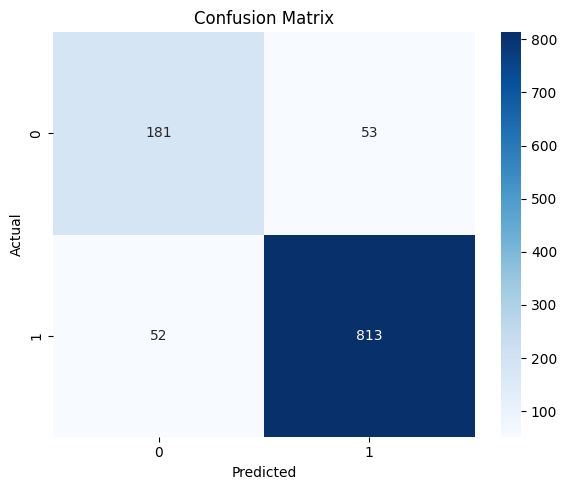

ROC Curve:


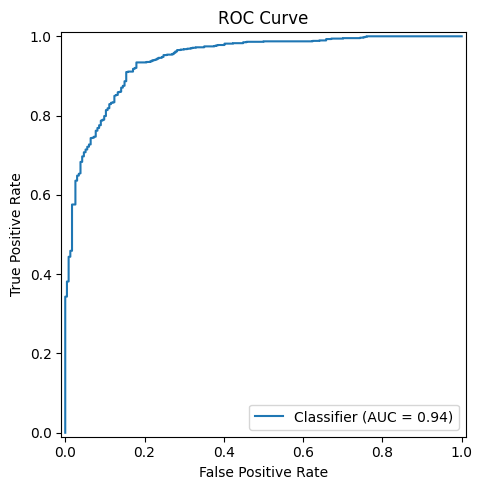

AUPRC Curve:


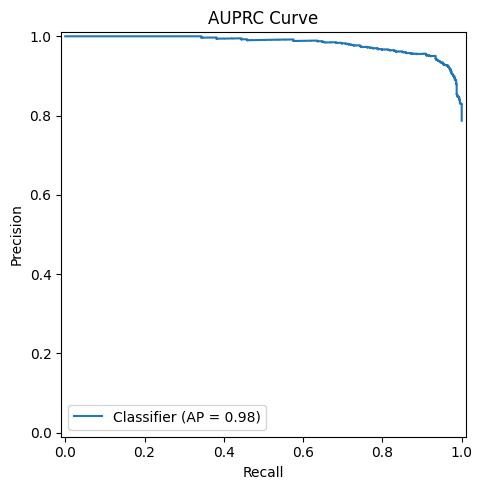

In [32]:
calc_metrics(final_model_xgb, model_name="xgboost_final", best_thr=best_thr)

In [37]:
# Train loss uses X_train_full (what the model was actually trained on)
calc_loss(final_model_xgb)


Log Loss(Test): 0.2825858179158849
Log Loss(Train): 0.21638715526150823
Focal Loss (Test Set): 0.0246


In [40]:
save_model(final_model_xgb, "xgboost_bioactivity_model", model_path="xgboost")

Model saved to saved_model/xgboost/


##### RandomForest

In [44]:
import warnings
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, average_precision_score,
    matthews_corrcoef, cohen_kappa_score, brier_score_loss,
    confusion_matrix, precision_recall_curve,
)

warnings.filterwarnings("ignore")

N_CV_SPLITS_RF = 5
RANDOM_STATE   = 42

# RF is scale-invariant — no per-fold scaler needed; use X_train directly
X_train_rf   = X_train.copy()
y_train_arr_rf = np.asarray(y_train)   # pandas Series → numpy to allow positional indexing

neg_count = (y_train_arr_rf == 0).sum()
pos_count = (y_train_arr_rf == 1).sum()
print(f"Class imbalance ratio (neg/pos): {neg_count / (pos_count + 1e-8):.2f}:1\n")

# ── Imbalance-aware fixed hyperparameters ─────────────────────────────────────
# Rationale for each choice:
#   class_weight='balanced_subsample' : per-tree reweighting based on each
#       bootstrap sample's class frequencies — stronger than 'balanced'
#       (global weights) for imbalanced data
#   n_estimators=500     : large forest for low-variance probability estimates
#   max_depth=15         : moderate depth to avoid overfitting on minority class
#   min_samples_split=5  : guards against splits driven by minority noise
#   min_samples_leaf=2   : requires minimum support per leaf
#   max_features='sqrt'  : standard for classification; adds diversity
rf_params = dict(
    n_estimators      = 500,
    max_depth         = 15,
    min_samples_split = 5,
    min_samples_leaf  = 2,
    max_features      = 'sqrt',
    class_weight      = 'balanced_subsample',
    criterion         = 'gini',
    oob_score         = True,
    n_jobs            = -1,
    random_state      = RANDOM_STATE,
)

print("RandomForest hyperparameters (imbalance-aware):")
for k, v in rf_params.items():
    print(f"  {k:>22} = {v}")

# ── 5-Fold CV evaluation with comprehensive metrics ───────────────────────────
fold         = StratifiedKFold(n_splits=N_CV_SPLITS_RF, shuffle=True, random_state=RANDOM_STATE)
oof_probs_rf = np.zeros(len(y_train_arr_rf))
fold_data_rf = []

FOLD_COLS = ['Acc', 'Bal.Acc', 'Prec', 'Rec', 'F1', 'AUC', 'AUPRC', 'MCC', 'Spec', 'Kappa', 'Brier']
hdr_line  = f"{'Fold':>6}  " + "  ".join(f"{c:>8}" for c in FOLD_COLS)
print(f"\n{hdr_line}")
print("-" * len(hdr_line))

for fold_idx, (tr_idx, val_idx) in enumerate(fold.split(X_train_rf, y_train_arr_rf)):
    X_tr, X_vf = X_train_rf[tr_idx].copy(), X_train_rf[val_idx].copy()
    y_tr, y_vf = y_train_arr_rf[tr_idx], y_train_arr_rf[val_idx]

    model_rf = RandomForestClassifier(**rf_params)
    model_rf.fit(X_tr, y_tr)

    probs = model_rf.predict_proba(X_vf)[:, 1]
    preds = (probs >= 0.5).astype(int)
    oof_probs_rf[val_idx] = probs

    tn, fp, fn, tp = confusion_matrix(y_vf, preds).ravel()
    spec = tn / (tn + fp + 1e-12)
    npv  = tn / (tn + fn + 1e-12)

    m = {
        'Acc':     accuracy_score(y_vf, preds),
        'Bal.Acc': balanced_accuracy_score(y_vf, preds),
        'Prec':    precision_score(y_vf, preds, zero_division=0),
        'Rec':     recall_score(y_vf, preds, zero_division=0),
        'F1':      f1_score(y_vf, preds, zero_division=0),
        'AUC':     roc_auc_score(y_vf, probs),
        'AUPRC':   average_precision_score(y_vf, probs),
        'MCC':     matthews_corrcoef(y_vf, preds),
        'Spec':    spec,
        'Kappa':   cohen_kappa_score(y_vf, preds),
        'Brier':   brier_score_loss(y_vf, probs),
        'NPV':     npv,
    }
    fold_data_rf.append(m)
    row_str = "  ".join(f"{m[c]:>8.4f}" for c in FOLD_COLS)
    print(f"{fold_idx + 1:>6}  {row_str}")

print("=" * len(hdr_line))

# ── Per-metric summary ────────────────────────────────────────────────────────
SUMMARY_MAP_RF = {
    'Accuracy':     'Acc',
    'Balanced Acc': 'Bal.Acc',
    'Precision':    'Prec',
    'Recall':       'Rec',
    'F1':           'F1',
    'ROC-AUC':      'AUC',
    'AUPRC':        'AUPRC',
    'MCC':          'MCC',
    'Sensitivity':  'Rec',
    'Specificity':  'Spec',
    'NPV':          'NPV',
    "Cohen's k":    'Kappa',
    'Brier':        'Brier',
}

def _ci95_rf(arr):
    se = np.std(arr, ddof=1) / np.sqrt(len(arr))
    return np.mean(arr) - 1.96 * se, np.mean(arr) + 1.96 * se

summary_rows_rf = {}
for label, col in SUMMARY_MAP_RF.items():
    vals = np.array([d[col] for d in fold_data_rf])
    lo, hi = _ci95_rf(vals)
    summary_rows_rf[label] = {
        'Mean +- Std': f"{np.mean(vals):.4f} +- {np.std(vals, ddof=1):.4f}",
        'Min':         f"{np.min(vals):.4f}",
        'Max':         f"{np.max(vals):.4f}",
        '95% CI':      f"[{lo:.4f}, {hi:.4f}]",
    }

summary_df_rf = pd.DataFrame(summary_rows_rf).T
summary_df_rf.index.name = 'Metric'
print(f"\n  Per-Metric Summary\n")
print(summary_df_rf.to_string())

# ── OOF threshold tuning ──────────────────────────────────────────────────────
oof_auc_rf = roc_auc_score(y_train_arr_rf, oof_probs_rf)
oof_ap_rf  = average_precision_score(y_train_arr_rf, oof_probs_rf)
prec_c, rec_c, thr_c = precision_recall_curve(y_train_arr_rf, oof_probs_rf)
f1s_rf     = 2 * prec_c * rec_c / (prec_c + rec_c + 1e-8)
best_thr_rf = float(thr_c[np.argmax(f1s_rf[:-1])])

print(f"\nOOF ROC-AUC  : {oof_auc_rf:.4f}")
print(f"OOF AUPRC    : {oof_ap_rf:.4f}")
print(f"Optimal thr  : {best_thr_rf:.3f}  (OOF F1-max threshold)")

# ── Paper-ready summary ───────────────────────────────────────────────────────
PAPER_METRICS_RF = ['Accuracy', 'ROC-AUC', 'F1', 'MCC', 'AUPRC',
                    'Sensitivity', 'Specificity', "Cohen's k", 'Brier']
paper_df_rf = pd.DataFrame(
    {m: [summary_rows_rf[m]['Mean +- Std']] for m in PAPER_METRICS_RF},
    index=[f'RandomForest ({N_CV_SPLITS_RF}-Fold CV)'],
).T
paper_df_rf.index.name = None
print(f"\n  Paper-Ready Summary\n")
print(paper_df_rf.to_string())


Class imbalance ratio (neg/pos): 0.27:1

RandomForest hyperparameters (imbalance-aware):
            n_estimators = 500
               max_depth = 15
       min_samples_split = 5
        min_samples_leaf = 2
            max_features = sqrt
            class_weight = balanced_subsample
               criterion = gini
               oob_score = True
                  n_jobs = -1
            random_state = 42

  Fold       Acc   Bal.Acc      Prec       Rec        F1       AUC     AUPRC       MCC      Spec     Kappa     Brier
--------------------------------------------------------------------------------------------------------------------
     1    0.9238    0.8769    0.9459    0.9582    0.9520    0.9432    0.9813    0.7678    0.7957    0.7674    0.0867
     2    0.9135    0.8709    0.9451    0.9451    0.9451    0.9463    0.9804    0.7419    0.7968    0.7419    0.0836
     3    0.9078    0.8537    0.9358    0.9480    0.9419    0.9328    0.9755    0.7203    0.7594    0.7200    0.0878
    

In [45]:
# ── Train final RandomForest on all train+val, then evaluate on held-out test ──
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, average_precision_score,
    matthews_corrcoef, cohen_kappa_score, brier_score_loss,
    confusion_matrix, classification_report,
)

X_train_full_rf = np.asarray(X_train)
y_train_full_rf = np.asarray(y_train)

final_model_rf = RandomForestClassifier(**rf_params)
final_model_rf.fit(X_train_full_rf, y_train_full_rf)
print(f"Final RF trained  |  threshold = {best_thr_rf:.3f}\n")

y_prob_rf = final_model_rf.predict_proba(X_test)[:, 1]
y_true_rf = np.asarray(y_test)

def _eval_rf(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return y_pred, {
        'Accuracy':     accuracy_score(y_true, y_pred),
        'Balanced Acc': balanced_accuracy_score(y_true, y_pred),
        'Precision':    precision_score(y_true, y_pred, zero_division=0),
        'Recall':       recall_score(y_true, y_pred, zero_division=0),
        'F1':           f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC':      roc_auc_score(y_true, y_prob),
        'AUPRC':        average_precision_score(y_true, y_prob),
        'MCC':          matthews_corrcoef(y_true, y_pred),
        'Specificity':  tn / (tn + fp + 1e-12),
        'NPV':          tn / (tn + fn + 1e-12),
        "Cohen's k":    cohen_kappa_score(y_true, y_pred),
        'Brier':        brier_score_loss(y_true, y_prob),
    }

y_pred_default_rf, m_default_rf = _eval_rf(y_true_rf, y_prob_rf, 0.50)
y_pred_tuned_rf,   m_tuned_rf   = _eval_rf(y_true_rf, y_prob_rf, best_thr_rf)

cmp_df_rf = pd.DataFrame({
    f'thr={best_thr_rf:.3f} (OOF-tuned)': m_tuned_rf,
})
print("  Test Set Comparison\n")
print(cmp_df_rf.to_string(float_format=lambda x: f"{x:.4f}"))

print(f"\n  Classification Report  (threshold = {best_thr_rf:.3f})\n")
print(classification_report(y_true_rf, y_pred_tuned_rf, target_names=['Inactive', 'Active']))


Final RF trained  |  threshold = 0.484

  Test Set Comparison

              thr=0.484 (OOF-tuned)
Accuracy                     0.9154
Balanced Acc                 0.8605
Precision                    0.9376
Recall                       0.9561
F1                           0.9468
ROC-AUC                      0.9478
AUPRC                        0.9840
MCC                          0.7415
Specificity                  0.7650
NPV                          0.8249
Cohen's k                    0.7407
Brier                        0.0843

  Classification Report  (threshold = 0.484)

              precision    recall  f1-score   support

    Inactive       0.82      0.76      0.79       234
      Active       0.94      0.96      0.95       865

    accuracy                           0.92      1099
   macro avg       0.88      0.86      0.87      1099
weighted avg       0.91      0.92      0.91      1099



Accuracy: 0.9154
Balanced Acc.: 0.8605
Cohen's Kappa: 0.7407
Precision: 0.9376
Recall: 0.9561
F1 Score: 0.9468
ROC-AUC: 0.9478
AUPRC: 0.9840
MCC: 0.7415
NPV: 0.8249
Specificity: 0.7650
Sensitivity: 0.9561
Informedness: 0.7210
DOR: 70.8292
Brier Score: 0.0843
********************
Confusion Matrix:


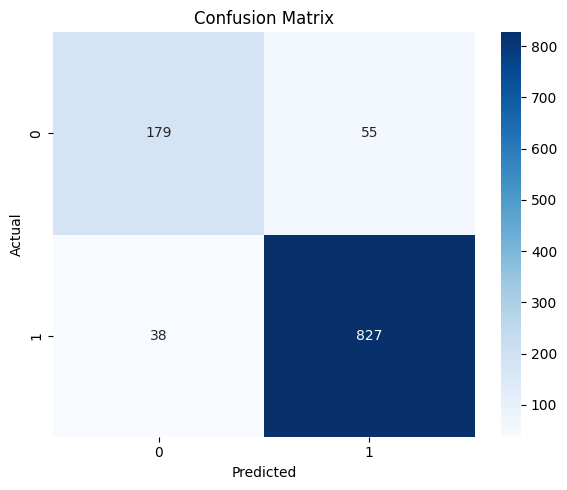

ROC Curve:


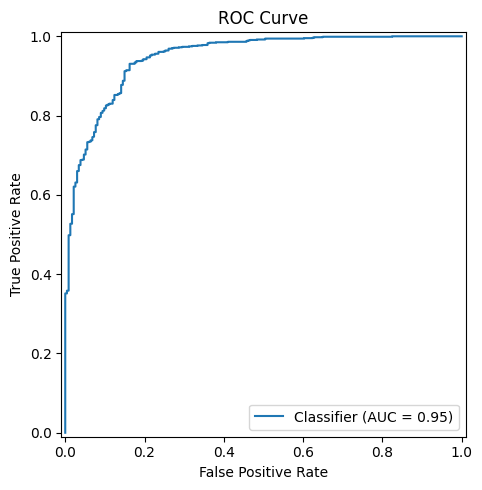

AUPRC Curve:


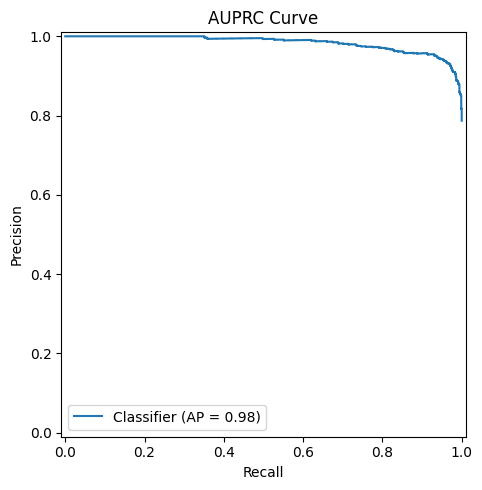

In [46]:
calc_metrics(final_model_rf, model_name="rf_final", best_thr=best_thr_rf)

In [ ]:
# Train loss on the full pool the model was trained on
calc_loss(final_model_rf)

from sklearn.metrics import log_loss
import numpy as np
train_ll = log_loss(y_train_full, final_model_rf.predict_proba(X_train_full))


Log Loss(Test): 0.3041012433328285
Log Loss(Train): 0.24181501220141416
Focal Loss (Test Set): 0.0153
Log Loss (Train+Val pool): 0.2418


In [48]:
save_model(final_model_rf, "random_forest_bioactivity_model", model_path="rf")


Model saved to saved_model/rf/


##### LightGBM

In [72]:
# ── LightGBM 5-Fold Stratified CV (imbalance-aware, no Optuna) ──────────────
import warnings
import numpy as np
import pandas as pd
import lightgbm as lgbm
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, average_precision_score,
    matthews_corrcoef, cohen_kappa_score, brier_score_loss,
    confusion_matrix, precision_recall_curve,
)

warnings.filterwarnings("ignore")

N_CV_SPLITS_LGBM = 5
EARLY_STOP_LGBM  = 50
NUM_BOOST_LGBM   = 1000

# Inverse-transform descriptor columns back to raw so each fold fits its own scaler
X_train_lgbm = X_train.copy()
X_train_lgbm[:, DESC_COLS] = scaler.inverse_transform(X_train[:, DESC_COLS])

# Convert y_train to numpy — StratifiedKFold returns positional indices but
# y_train is a pandas Series with non-contiguous original DataFrame labels
y_train_arr_lgbm = np.asarray(y_train)

# Compute imbalance ratio from y_train
neg_count_lgbm = (y_train_arr_lgbm == 0).sum()
pos_count_lgbm = (y_train_arr_lgbm == 1).sum()
global_imbalance_ratio_lgbm = neg_count_lgbm / (pos_count_lgbm + 1e-8)
print(f"Class imbalance ratio (neg/pos): {global_imbalance_ratio_lgbm:.2f}:1\n")

# ── Imbalance-aware fixed hyperparameters ─────────────────────────────────────
# scale_pos_weight  : compensates class imbalance (neg/pos ratio)
# num_leaves=31     : default; conservative to prevent overfitting on minority
# min_child_samples : requires more samples per leaf — guards against minority noise
# subsample + freq  : row sub-sampling per tree for variance reduction
# colsample_bytree  : feature sub-sampling for diversity
# reg_alpha/lambda  : L1/L2 regularisation for smoother probability estimates
# metric=auprc      : optimise area under precision-recall curve (imbalance-sensitive)
lgbm_params = dict(
    n_estimators      = NUM_BOOST_LGBM,
    learning_rate     = 0.05,
    max_depth         = 6,
    num_leaves        = 31,
    min_child_samples = 10,
    subsample         = 0.80,
    subsample_freq    = 1,
    colsample_bytree  = 0.70,
    reg_alpha         = 0.10,
    reg_lambda        = 1.50,
    bagging_fraction  = 0.80,
    bagging_freq      = 1,
    boosting_type     = 'gbdt',
    objective         = 'binary',
    metric            = 'average_precision',
    verbosity         = -1,
    n_jobs            = -1,
    random_state      = RANDOM_STATE,
)

print("LightGBM hyperparameters (imbalance-aware):")
for k, v in lgbm_params.items():
    print(f"  {k:>22} = {v}")

# ── 5-Fold CV loop ────────────────────────────────────────────────────────────
cv_lgbm      = StratifiedKFold(n_splits=N_CV_SPLITS_LGBM, shuffle=True, random_state=RANDOM_STATE)
oof_probs_lgbm  = np.zeros(len(y_train_arr_lgbm))
best_iters_lgbm = []
fold_data_lgbm  = []

FOLD_COLS_LGBM = ['Acc', 'Bal.Acc', 'Prec', 'Rec', 'F1', 'AUC', 'AUPRC', 'MCC', 'Spec', 'Kappa', 'Brier']
hdr_line_lgbm  = f"{'Fold':>6}  " + "  ".join(f"{c:>8}" for c in FOLD_COLS_LGBM)
print(f"\n{hdr_line_lgbm}")
print("-" * len(hdr_line_lgbm))

for fold_idx, (tr_idx, val_idx) in enumerate(cv_lgbm.split(X_train_lgbm, y_train_arr_lgbm)):
    X_tr, X_vf = X_train_lgbm[tr_idx].copy(), X_train_lgbm[val_idx].copy()
    y_tr, y_vf = y_train_arr_lgbm[tr_idx], y_train_arr_lgbm[val_idx]

    fs = StandardScaler()
    X_tr[:, DESC_COLS] = fs.fit_transform(X_tr[:, DESC_COLS])
    X_vf[:, DESC_COLS] = fs.transform(X_vf[:, DESC_COLS])

    # Per-fold imbalance ratio for scale_pos_weight
    neg_w = 1.0 / ((y_tr == 0).mean() + 1e-12)
    pos_w = 1.0 / ((y_tr == 1).mean() + 1e-12)
    sw    = np.where(y_tr == 1, pos_w, neg_w)
    fold_spw = (y_tr == 0).sum() / ((y_tr == 1).sum() + 1e-8)

    model = lgbm.LGBMClassifier(**lgbm_params)
    model.fit(
        X_tr, y_tr,
        sample_weight=sw,
        eval_set=[(X_vf, y_vf)],
        callbacks=[
            lgbm.early_stopping(EARLY_STOP_LGBM, verbose=False),
            lgbm.log_evaluation(-1),
        ],
    )

    probs = model.predict_proba(X_vf)[:, 1]
    preds = (probs >= 0.5).astype(int)
    oof_probs_lgbm[val_idx] = probs
    best_iters_lgbm.append(model.best_iteration_)

    tn, fp, fn, tp = confusion_matrix(y_vf, preds).ravel()
    spec = tn / (tn + fp + 1e-12)
    npv  = tn / (tn + fn + 1e-12)

    m = {
        'Acc':     accuracy_score(y_vf, preds),
        'Bal.Acc': balanced_accuracy_score(y_vf, preds),
        'Prec':    precision_score(y_vf, preds, zero_division=0),
        'Rec':     recall_score(y_vf, preds, zero_division=0),
        'F1':      f1_score(y_vf, preds, zero_division=0),
        'AUC':     roc_auc_score(y_vf, probs),
        'AUPRC':   average_precision_score(y_vf, probs),
        'MCC':     matthews_corrcoef(y_vf, preds),
        'Spec':    spec,
        'Kappa':   cohen_kappa_score(y_vf, preds),
        'Brier':   brier_score_loss(y_vf, probs),
        'NPV':     npv,
    }
    fold_data_lgbm.append(m)
    row_str = "  ".join(f"{m[c]:>8.4f}" for c in FOLD_COLS_LGBM)
    print(f"{fold_idx + 1:>6}  {row_str}")

print("=" * len(hdr_line_lgbm))

# ── Per-metric summary ────────────────────────────────────────────────────────
SUMMARY_MAP_LGBM = {
    'Accuracy':     'Acc',
    'Balanced Acc': 'Bal.Acc',
    'Precision':    'Prec',
    'Recall':       'Rec',
    'F1':           'F1',
    'ROC-AUC':      'AUC',
    'AUPRC':        'AUPRC',
    'MCC':          'MCC',
    'Sensitivity':  'Rec',
    'Specificity':  'Spec',
    'NPV':          'NPV',
    "Cohen's k":    'Kappa',
    'Brier':        'Brier',
}

def _ci95_lgbm(arr):
    se = np.std(arr, ddof=1) / np.sqrt(len(arr))
    return np.mean(arr) - 1.96 * se, np.mean(arr) + 1.96 * se

summary_rows_lgbm = {}
for label, col in SUMMARY_MAP_LGBM.items():
    vals = np.array([d[col] for d in fold_data_lgbm])
    lo, hi = _ci95_lgbm(vals)
    summary_rows_lgbm[label] = {
        'Mean +- Std': f"{np.mean(vals):.4f} +- {np.std(vals, ddof=1):.4f}",
        'Min':         f"{np.min(vals):.4f}",
        'Max':         f"{np.max(vals):.4f}",
        '95% CI':      f"[{lo:.4f}, {hi:.4f}]",
    }

summary_df_lgbm = pd.DataFrame(summary_rows_lgbm).T
summary_df_lgbm.index.name = 'Metric'
print(f"\n  Per-Metric Summary\n")
print(summary_df_lgbm.to_string())

# ── OOF threshold tuning ──────────────────────────────────────────────────────
oof_auc_lgbm  = roc_auc_score(y_train_arr_lgbm, oof_probs_lgbm)
oof_ap_lgbm   = average_precision_score(y_train_arr_lgbm, oof_probs_lgbm)
prec_c, rec_c, thr_c = precision_recall_curve(y_train_arr_lgbm, oof_probs_lgbm)
f1s_lgbm      = 2 * prec_c * rec_c / (prec_c + rec_c + 1e-8)
best_thr_lgbm = float(thr_c[np.argmax(f1s_lgbm[:-1])])
best_n_trees_lgbm = int(np.mean(best_iters_lgbm))

print(f"\nOOF ROC-AUC  : {oof_auc_lgbm:.4f}")
print(f"OOF AUPRC    : {oof_ap_lgbm:.4f}")
print(f"Optimal thr  : {best_thr_lgbm:.3f}  (OOF F1-max threshold)")
print(f"Avg best_iter: {best_n_trees_lgbm}  -> use as n_estimators for final model")

# ── Paper-ready summary ───────────────────────────────────────────────────────
PAPER_METRICS_LGBM = ['Accuracy', 'ROC-AUC', 'F1', 'MCC', 'AUPRC',
                      'Sensitivity', 'Specificity', "Cohen's k", 'Brier']
paper_df_lgbm = pd.DataFrame(
    {m: [summary_rows_lgbm[m]['Mean +- Std']] for m in PAPER_METRICS_LGBM},
    index=[f'LightGBM ({N_CV_SPLITS_LGBM}-Fold CV)'],
).T
paper_df_lgbm.index.name = None
print(f"\n  Paper-Ready Summary\n")
print(paper_df_lgbm.to_string())


Class imbalance ratio (neg/pos): 0.27:1

LightGBM hyperparameters (imbalance-aware):
            n_estimators = 1000
           learning_rate = 0.05
               max_depth = 6
              num_leaves = 31
       min_child_samples = 10
               subsample = 0.8
          subsample_freq = 1
        colsample_bytree = 0.7
               reg_alpha = 0.1
              reg_lambda = 1.5
        bagging_fraction = 0.8
            bagging_freq = 1
           boosting_type = gbdt
               objective = binary
                  metric = average_precision
               verbosity = -1
                  n_jobs = -1
            random_state = 42

  Fold       Acc   Bal.Acc      Prec       Rec        F1       AUC     AUPRC       MCC      Spec     Kappa     Brier
--------------------------------------------------------------------------------------------------------------------
     1    0.9238    0.9064    0.9658    0.9365    0.9509    0.9463    0.9809    0.7825    0.8763    0.7806    0.0

In [73]:
# ── Train final LightGBM on all train+val, then evaluate on held-out test set ──
import numpy as np
import pandas as pd
import lightgbm as lgbm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, average_precision_score,
    matthews_corrcoef, cohen_kappa_score, brier_score_loss,
    confusion_matrix, classification_report,
)

# ── Leakage-free preprocessing ────────────────────────────────────────────────
# Inverse-transform everything back to raw, then fit a fresh scaler on the
# full training pool (train+val) so train, val and test are all consistently scaled.
X_train_raw_lgbm = X_train.copy()
X_train_raw_lgbm[:, DESC_COLS] = scaler.inverse_transform(X_train[:, DESC_COLS])

X_test_raw_lgbm = X_test.copy()
X_test_raw_lgbm[:, DESC_COLS] = scaler.inverse_transform(X_test[:, DESC_COLS])

final_scaler_lgbm = StandardScaler()
X_train_raw_lgbm[:, DESC_COLS] = final_scaler_lgbm.fit_transform(X_train_raw_lgbm[:, DESC_COLS])
X_test_raw_lgbm[:, DESC_COLS] = final_scaler_lgbm.transform(X_test_raw_lgbm[:, DESC_COLS])

y_train_raw_lgbm = np.asarray(y_train)  # convert to numpy for consistency with CV folds

# ── Imbalance ratio from full training pool ───────────────────────────────────
final_imbalance_ratio_lgbm = (y_train_raw_lgbm == 0).sum() / ((y_train_raw_lgbm == 1).sum() + 1e-8)
print(f"Final training pool imbalance ratio: {final_imbalance_ratio_lgbm:.2f}:1\n")

# Same hyperparams as CV; n_estimators = avg best_iter from folds; no early stopping
final_params_lgbm = {k: v for k, v in lgbm_params.items()}
final_params_lgbm['n_estimators']     = best_n_trees_lgbm
final_params_lgbm['scale_pos_weight'] = final_imbalance_ratio_lgbm

final_model_lgbm = lgbm.LGBMClassifier(**final_params_lgbm)
final_model_lgbm.fit(X_train_raw_lgbm, y_train_raw_lgbm,
                     callbacks=[lgbm.log_evaluation(-1)])
print(f"Final model trained  |  n_estimators = {best_n_trees_lgbm}  |  threshold = {best_thr_lgbm:.3f}\n")

y_prob_lgbm = final_model_lgbm.predict_proba(X_test_raw_lgbm)[:, 1]
y_true_lgbm = np.asarray(y_test)

def _eval_lgbm(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return y_pred, {
        'Accuracy':     accuracy_score(y_true, y_pred),
        'Balanced Acc': balanced_accuracy_score(y_true, y_pred),
        'Precision':    precision_score(y_true, y_pred, zero_division=0),
        'Recall':       recall_score(y_true, y_pred, zero_division=0),
        'F1':           f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC':      roc_auc_score(y_true, y_prob),
        'AUPRC':        average_precision_score(y_true, y_prob),
        'MCC':          matthews_corrcoef(y_true, y_pred),
        'Specificity':  tn / (tn + fp + 1e-12),
        'NPV':          tn / (tn + fn + 1e-12),
        "Cohen's k":    cohen_kappa_score(y_true, y_pred),
        'Brier':        brier_score_loss(y_true, y_prob),
    }

y_pred_default_lgbm, m_default_lgbm = _eval_lgbm(y_true_lgbm, y_prob_lgbm, 0.50)
y_pred_tuned_lgbm,   m_tuned_lgbm   = _eval_lgbm(y_true_lgbm, y_prob_lgbm, best_thr_lgbm)

cmp_df_lgbm = pd.DataFrame({
    #'thr=0.500 (default)':                  m_default_lgbm,
    f'thr={best_thr_lgbm:.3f} (OOF-tuned)': m_tuned_lgbm,
})
print("  Test Set Comparison\n")
print(cmp_df_lgbm.to_string(float_format=lambda x: f"{x:.4f}"))

print(f"\n  Classification Report  (threshold = {best_thr_lgbm:.3f})\n")
print(classification_report(y_true_lgbm, y_pred_tuned_lgbm, target_names=['Inactive', 'Active']))


Final training pool imbalance ratio: 0.27:1

Final model trained  |  n_estimators = 236  |  threshold = 0.379

  Test Set Comparison

              thr=0.379 (OOF-tuned)
Accuracy                     0.9245
Balanced Acc                 0.8741
Precision                    0.9433
Recall                       0.9618
F1                           0.9525
ROC-AUC                      0.9507
AUPRC                        0.9850
MCC                          0.7694
Specificity                  0.7863
NPV                          0.8479
Cohen's k                    0.7685
Brier                        0.0697

  Classification Report  (threshold = 0.379)

              precision    recall  f1-score   support

    Inactive       0.85      0.79      0.82       234
      Active       0.94      0.96      0.95       865

    accuracy                           0.92      1099
   macro avg       0.90      0.87      0.88      1099
weighted avg       0.92      0.92      0.92      1099



Accuracy: 0.9245
Balanced Acc.: 0.8741
Cohen's Kappa: 0.7685
Precision: 0.9433
Recall: 0.9618
F1 Score: 0.9525
ROC-AUC: 0.9507
AUPRC: 0.9850
MCC: 0.7694
NPV: 0.8479
Specificity: 0.7863
Sensitivity: 0.9618
Informedness: 0.7482
DOR: 92.7806
Brier Score: 0.0697
********************
Confusion Matrix:


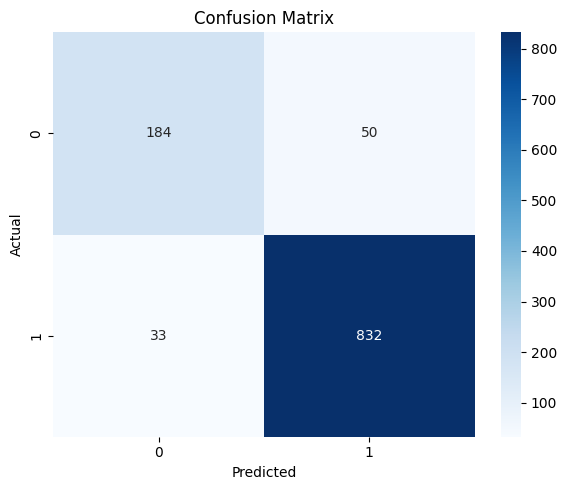

ROC Curve:


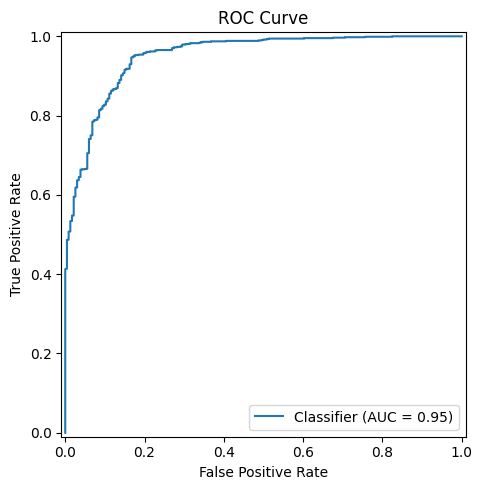

AUPRC Curve:


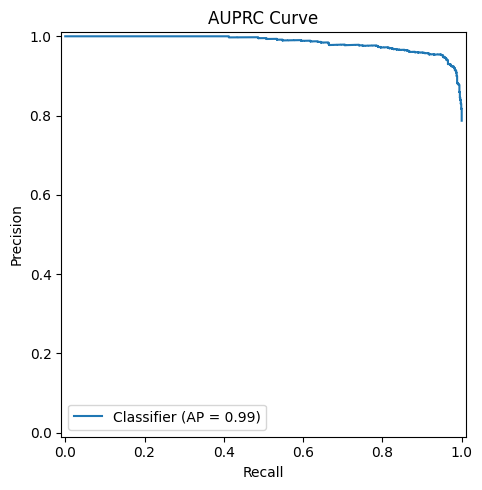

In [74]:
calc_metrics(final_model_lgbm, best_thr=best_thr_lgbm, model_name="lgbm_final")

In [75]:
# Train loss on the full pool the model was trained on
from sklearn.metrics import log_loss
import numpy as np

train_ll_lgbm = log_loss(y_train_raw_lgbm,
                         final_model_lgbm.predict_proba(X_train_raw_lgbm))
print(f"\nFinal model train log-loss: {train_ll_lgbm:.4f}\n")



Final model train log-loss: 0.1605



In [76]:
save_model(final_model_lgbm, "lightgbm_bioactivity_model", model_path="lgbm")


Model saved to saved_model/lgbm/


##### CatBoost

In [77]:
# ── CatBoost 5-Fold Stratified CV (imbalance-aware, no Optuna) ──────────────
import warnings
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, average_precision_score,
    matthews_corrcoef, cohen_kappa_score, brier_score_loss,
    confusion_matrix, precision_recall_curve,
)

warnings.filterwarnings("ignore")

N_CV_SPLITS_CAT = 5
EARLY_STOP_CAT  = 50
NUM_BOOST_CAT   = 1000

# Inverse-transform descriptor columns back to raw so each fold fits its own scaler
X_train_cat = X_train.copy()
X_train_cat[:, DESC_COLS] = scaler.inverse_transform(X_train[:, DESC_COLS])

# Convert y_train to numpy — StratifiedKFold returns positional indices but
# y_train is a pandas Series with non-contiguous original DataFrame labels
y_train_arr_cat = np.asarray(y_train)

# Compute imbalance ratio from y_train
neg_count_cat = (y_train_arr_cat == 0).sum()
pos_count_cat = (y_train_arr_cat == 1).sum()
global_imbalance_ratio_cat = neg_count_cat / (pos_count_cat + 1e-8)
print(f"Class imbalance ratio (neg/pos): {global_imbalance_ratio_cat:.2f}:1\n")

# ── Imbalance-aware fixed hyperparameters ─────────────────────────────────────
# scale_pos_weight    : compensates class imbalance (neg/pos ratio)
# depth=6             : controls tree depth (analogue of max_depth in XGBoost)
# l2_leaf_reg         : L2 regularisation on leaf weights
# bagging_temperature : Bayesian bootstrap intensity; 0=no bagging, 1=standard
# random_strength     : adds noise to split scoring → regularises minority noise
# border_count        : number of candidate splits per numerical feature
# eval_metric=PRAUC   : precision-recall AUC (imbalance-sensitive, like XGBoost aucpr)
cat_params = dict(
    iterations          = NUM_BOOST_CAT,
    learning_rate       = 0.05,
    depth               = 6,
    l2_leaf_reg         = 3.0,
    bagging_temperature = 0.5,
    random_strength     = 1.0,
    border_count        = 128,
    rsm                 = 0.30,
    eval_metric         = "PRAUC",
    verbose             = False,
    thread_count        = -1,
    random_seed         = RANDOM_STATE,
)

print("CatBoost hyperparameters (imbalance-aware):")
for k, v in cat_params.items():
    print(f"  {k:>22} = {v}")

# ── 5-Fold CV loop ────────────────────────────────────────────────────────────
cv_cat         = StratifiedKFold(n_splits=N_CV_SPLITS_CAT, shuffle=True, random_state=RANDOM_STATE)
oof_probs_cat  = np.zeros(len(y_train_arr_cat))
best_iters_cat = []
fold_data_cat  = []

FOLD_COLS_CAT = ['Acc', 'Bal.Acc', 'Prec', 'Rec', 'F1', 'AUC', 'AUPRC', 'MCC', 'Spec', 'Kappa', 'Brier']
hdr_line_cat  = f"{'Fold':>6}  " + "  ".join(f"{c:>8}" for c in FOLD_COLS_CAT)
print(f"\n{hdr_line_cat}")
print("-" * len(hdr_line_cat))

for fold_idx, (tr_idx, val_idx) in enumerate(cv_cat.split(X_train_cat, y_train_arr_cat)):
    X_tr, X_vf = X_train_cat[tr_idx].copy(), X_train_cat[val_idx].copy()
    y_tr, y_vf = y_train_arr_cat[tr_idx], y_train_arr_cat[val_idx]

    fs = StandardScaler()
    X_tr[:, DESC_COLS] = fs.fit_transform(X_tr[:, DESC_COLS])
    X_vf[:, DESC_COLS] = fs.transform(X_vf[:, DESC_COLS])

    fold_spw = (y_tr == 0).sum() / ((y_tr == 1).sum() + 1e-8)

    model = CatBoostClassifier(**cat_params, scale_pos_weight=fold_spw)
    model.fit(
        X_tr, y_tr,
        eval_set=(X_vf, y_vf),
        early_stopping_rounds=EARLY_STOP_CAT,
        verbose=False,
    )

    bi = model.best_iteration_
    best_iters_cat.append(bi if bi is not None else NUM_BOOST_CAT)

    probs = model.predict_proba(X_vf)[:, 1]
    preds = (probs >= 0.5).astype(int)
    oof_probs_cat[val_idx] = probs

    tn, fp, fn, tp = confusion_matrix(y_vf, preds).ravel()
    spec = tn / (tn + fp + 1e-12)
    npv  = tn / (tn + fn + 1e-12)

    m = {
        'Acc':     accuracy_score(y_vf, preds),
        'Bal.Acc': balanced_accuracy_score(y_vf, preds),
        'Prec':    precision_score(y_vf, preds, zero_division=0),
        'Rec':     recall_score(y_vf, preds, zero_division=0),
        'F1':      f1_score(y_vf, preds, zero_division=0),
        'AUC':     roc_auc_score(y_vf, probs),
        'AUPRC':   average_precision_score(y_vf, probs),
        'MCC':     matthews_corrcoef(y_vf, preds),
        'Spec':    spec,
        'Kappa':   cohen_kappa_score(y_vf, preds),
        'Brier':   brier_score_loss(y_vf, probs),
        'NPV':     npv,
    }
    fold_data_cat.append(m)
    row_str = "  ".join(f"{m[c]:>8.4f}" for c in FOLD_COLS_CAT)
    print(f"{fold_idx + 1:>6}  {row_str}")

print("=" * len(hdr_line_cat))

# ── Per-metric summary ────────────────────────────────────────────────────────
SUMMARY_MAP_CAT = {
    'Accuracy':     'Acc',
    'Balanced Acc': 'Bal.Acc',
    'Precision':    'Prec',
    'Recall':       'Rec',
    'F1':           'F1',
    'ROC-AUC':      'AUC',
    'AUPRC':        'AUPRC',
    'MCC':          'MCC',
    'Sensitivity':  'Rec',
    'Specificity':  'Spec',
    'NPV':          'NPV',
    "Cohen's k":    'Kappa',
    'Brier':        'Brier',
}

def _ci95_cat(arr):
    se = np.std(arr, ddof=1) / np.sqrt(len(arr))
    return np.mean(arr) - 1.96 * se, np.mean(arr) + 1.96 * se

summary_rows_cat = {}
for label, col in SUMMARY_MAP_CAT.items():
    vals = np.array([d[col] for d in fold_data_cat])
    lo, hi = _ci95_cat(vals)
    summary_rows_cat[label] = {
        'Mean +- Std': f"{np.mean(vals):.4f} +- {np.std(vals, ddof=1):.4f}",
        'Min':         f"{np.min(vals):.4f}",
        'Max':         f"{np.max(vals):.4f}",
        '95% CI':      f"[{lo:.4f}, {hi:.4f}]",
    }

summary_df_cat = pd.DataFrame(summary_rows_cat).T
summary_df_cat.index.name = 'Metric'
print(f"\n  Per-Metric Summary\n")
print(summary_df_cat.to_string())

# ── OOF threshold tuning ──────────────────────────────────────────────────────
oof_auc_cat  = roc_auc_score(y_train_arr_cat, oof_probs_cat)
oof_ap_cat   = average_precision_score(y_train_arr_cat, oof_probs_cat)
prec_c, rec_c, thr_c = precision_recall_curve(y_train_arr_cat, oof_probs_cat)
f1s_cat      = 2 * prec_c * rec_c / (prec_c + rec_c + 1e-8)
best_thr_cat = float(thr_c[np.argmax(f1s_cat[:-1])])
best_n_trees_cat = int(np.mean(best_iters_cat))

print(f"\nOOF ROC-AUC  : {oof_auc_cat:.4f}")
print(f"OOF AUPRC    : {oof_ap_cat:.4f}")
print(f"Optimal thr  : {best_thr_cat:.3f}  (OOF F1-max threshold)")
print(f"Avg best_iter: {best_n_trees_cat}  -> use as iterations for final model")

# ── Paper-ready summary ───────────────────────────────────────────────────────
PAPER_METRICS_CAT = ['Accuracy', 'ROC-AUC', 'F1', 'MCC', 'AUPRC',
                     'Sensitivity', 'Specificity', "Cohen's k", 'Brier']
paper_df_cat = pd.DataFrame(
    {m: [summary_rows_cat[m]['Mean +- Std']] for m in PAPER_METRICS_CAT},
    index=[f'CatBoost ({N_CV_SPLITS_CAT}-Fold CV)'],
).T
paper_df_cat.index.name = None
print(f"\n  Paper-Ready Summary\n")
print(paper_df_cat.to_string())


Class imbalance ratio (neg/pos): 0.27:1

CatBoost hyperparameters (imbalance-aware):
              iterations = 1000
           learning_rate = 0.05
                   depth = 6
             l2_leaf_reg = 3.0
     bagging_temperature = 0.5
         random_strength = 1.0
            border_count = 128
                     rsm = 0.3
             eval_metric = PRAUC
                 verbose = False
            thread_count = -1
             random_seed = 42

  Fold       Acc   Bal.Acc      Prec       Rec        F1       AUC     AUPRC       MCC      Spec     Kappa     Brier
--------------------------------------------------------------------------------------------------------------------
     1    0.9283    0.8955    0.9565    0.9524    0.9544    0.9476    0.9810    0.7865    0.8387    0.7865    0.0621
     2    0.9078    0.8829    0.9553    0.9263    0.9406    0.9545    0.9844    0.7375    0.8396    0.7357    0.0696
     3    0.9033    0.8664    0.9457    0.9306    0.9381    0.9328    0.

In [78]:
# ── Train final CatBoost on all train+val, then evaluate on held-out test set ──
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, average_precision_score,
    matthews_corrcoef, cohen_kappa_score, brier_score_loss,
    confusion_matrix, classification_report,
)

# ── Leakage-free preprocessing ────────────────────────────────────────────────
X_train_raw_cat = X_train.copy()
X_train_raw_cat[:, DESC_COLS] = scaler.inverse_transform(X_train[:, DESC_COLS])

X_test_raw_cat = X_test.copy()
X_test_raw_cat[:, DESC_COLS] = scaler.inverse_transform(X_test[:, DESC_COLS])

final_scaler_cat = StandardScaler()
X_train_raw_cat[:, DESC_COLS] = final_scaler_cat.fit_transform(X_train_raw_cat[:, DESC_COLS])

X_test_final_cat = X_test_raw_cat.copy()
X_test_final_cat[:, DESC_COLS] = final_scaler_cat.transform(X_test_raw_cat[:, DESC_COLS])

# ── Imbalance ratio from full training pool ───────────────────────────────────
final_imbalance_ratio_cat = (y_train_arr_cat == 0).sum() / ((y_train_arr_cat == 1).sum() + 1e-8)
print(f"Final training pool imbalance ratio: {final_imbalance_ratio_cat:.2f}:1\n")

# Same hyperparams as CV; iterations = avg best_iter from folds; no early stopping
final_params_cat = {k: v for k, v in cat_params.items()}
final_params_cat['iterations']      = best_n_trees_cat
final_params_cat['scale_pos_weight'] = final_imbalance_ratio_cat

final_model_cat = CatBoostClassifier(**final_params_cat)
final_model_cat.fit(X_train_raw_cat, y_train_arr_cat, verbose=False)
print(f"Final model trained  |  iterations = {best_n_trees_cat}  |  threshold = {best_thr_cat:.3f}\n")

y_prob_cat = final_model_cat.predict_proba(X_test_final_cat)[:, 1]
y_true_cat = np.asarray(y_test)

def _eval_cat(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return y_pred, {
        'Accuracy':     accuracy_score(y_true, y_pred),
        'Balanced Acc': balanced_accuracy_score(y_true, y_pred),
        'Precision':    precision_score(y_true, y_pred, zero_division=0),
        'Recall':       recall_score(y_true, y_pred, zero_division=0),
        'F1':           f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC':      roc_auc_score(y_true, y_prob),
        'AUPRC':        average_precision_score(y_true, y_prob),
        'MCC':          matthews_corrcoef(y_true, y_pred),
        'Specificity':  tn / (tn + fp + 1e-12),
        'NPV':          tn / (tn + fn + 1e-12),
        "Cohen's k":    cohen_kappa_score(y_true, y_pred),
        'Brier':        brier_score_loss(y_true, y_prob),
    }
#
#y_pred_default_cat, m_default_cat = _eval_cat(y_true_cat, y_prob_cat, 0.50)
y_pred_tuned_cat,   m_tuned_cat   = _eval_cat(y_true_cat, y_prob_cat, 0.4)

cmp_df_cat = pd.DataFrame({
    f'thr={best_thr_cat:.3f} (OOF-tuned)': m_tuned_cat,
})
print("  Test Set Comparison\n")
print(cmp_df_cat.to_string(float_format=lambda x: f"{x:.4f}"))

print(f"\n  Classification Report  (threshold = {best_thr_cat:.3f})\n")
print(classification_report(y_true_cat, y_pred_tuned_cat, target_names=['Inactive', 'Active']))


Final training pool imbalance ratio: 0.27:1

Final model trained  |  iterations = 290  |  threshold = 0.373

  Test Set Comparison

              thr=0.373 (OOF-tuned)
Accuracy                     0.9227
Balanced Acc                 0.8729
Precision                    0.9432
Recall                       0.9595
F1                           0.9513
ROC-AUC                      0.9465
AUPRC                        0.9825
MCC                          0.7644
Specificity                  0.7863
NPV                          0.8402
Cohen's k                    0.7637
Brier                        0.0724

  Classification Report  (threshold = 0.373)

              precision    recall  f1-score   support

    Inactive       0.84      0.79      0.81       234
      Active       0.94      0.96      0.95       865

    accuracy                           0.92      1099
   macro avg       0.89      0.87      0.88      1099
weighted avg       0.92      0.92      0.92      1099



Accuracy: 0.9245
Balanced Acc.: 0.8679
Cohen's Kappa: 0.7655
Precision: 0.9393
Recall: 0.9665
F1 Score: 0.9527
ROC-AUC: 0.9465
AUPRC: 0.9825
MCC: 0.7675
NPV: 0.8612
Specificity: 0.7692
Sensitivity: 0.9665
Informedness: 0.7357
DOR: 96.0920
Brier Score: 0.0724
********************
Confusion Matrix:


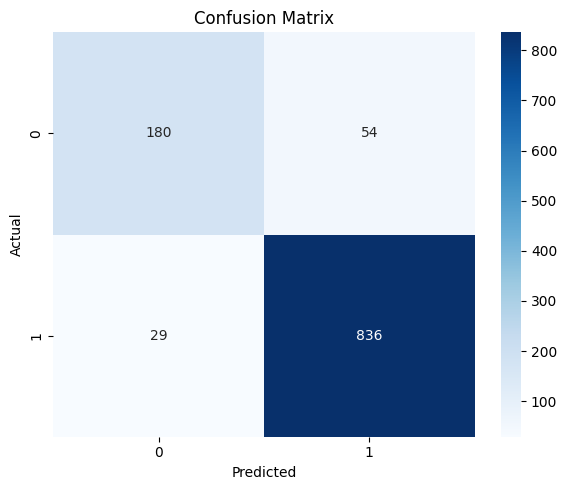

ROC Curve:


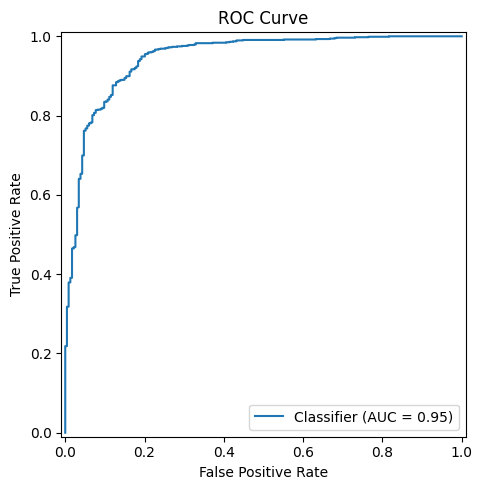

AUPRC Curve:


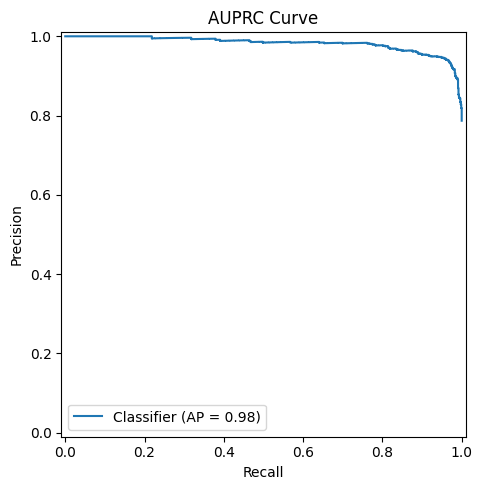

In [79]:
calc_metrics(final_model_cat, best_thr=best_thr_cat, model_name="cat_final")

In [60]:
# Train loss on the full pool the model was trained on
from sklearn.metrics import log_loss
import numpy as np

train_ll_cat = log_loss(y_train_arr_cat,
                        final_model_cat.predict_proba(X_train_raw_cat))
print(f"Log Loss (Train+Val pool): {train_ll_cat:.4f}")


Log Loss (Train+Val pool): 0.1784


In [61]:
save_model(final_model_cat, "catboost_bioactivity_model", model_path="catboost")


Model saved to saved_model/catboost/


##### ExtraTree Classifier

In [83]:
# ── ExtraTrees 5-Fold Stratified CV (imbalance-aware, no Optuna) ─────────────
import warnings
import numpy as np
import pandas as pd
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, average_precision_score,
    matthews_corrcoef, cohen_kappa_score, brier_score_loss,
    confusion_matrix, precision_recall_curve,
)

warnings.filterwarnings("ignore")

N_CV_SPLITS_ET = 5

# Inverse-transform descriptor columns back to raw so each fold fits its own scaler
# (X_train was pre-scaled by the global StandardScaler; Morgan fingerprints at
#  0:1024 are binary — no inversion needed for those columns)
X_train_raw_et = X_train.copy()
X_train_raw_et[:, DESC_COLS] = scaler.inverse_transform(X_train[:, DESC_COLS])

# Convert y_train to numpy — StratifiedKFold returns positional indices but
# y_train is a pandas Series with non-contiguous original DataFrame labels
y_train_arr_et = np.asarray(y_train)

print(f"Class imbalance ratio (neg/pos): "
      f"{(y_train_arr_et==0).sum() / ((y_train_arr_et==1).sum() + 1e-8):.2f}:1\n")

# ── Imbalance-aware fixed hyperparameters ─────────────────────────────────────
# class_weight='balanced_subsample' : per-tree reweighting based on each
#   bootstrap sample's class frequencies — stronger than global 'balanced'
# max_depth=None    : ExtraTrees fully grown (extreme randomisation controls
#   variance; deep trees are less harmful than in standard trees)
# min_samples_split/leaf : guard against minority-class noise driving splits
# max_features='sqrt': feature sub-sampling for diversity across trees
et_params = dict(
    n_estimators      = 500,
    max_depth         = None,
    min_samples_split = 5,
    min_samples_leaf  = 2,
    max_features      = 'sqrt',
    class_weight      = 'balanced_subsample',
    criterion         = 'gini',
    n_jobs            = -1,
    bootstrap         = False,
    random_state      = RANDOM_STATE,
)

print("ExtraTrees hyperparameters (imbalance-aware):")
for k, v in et_params.items():
    print(f"  {k:>22} = {v}")

# ── 5-Fold CV loop ────────────────────────────────────────────────────────────
cv_et         = StratifiedKFold(n_splits=N_CV_SPLITS_ET, shuffle=True, random_state=RANDOM_STATE)
oof_probs_et  = np.zeros(len(y_train_arr_et))
fold_data_et  = []

FOLD_COLS_ET = ['Acc', 'Bal.Acc', 'Prec', 'Rec', 'F1', 'AUC', 'AUPRC', 'MCC', 'Spec', 'Kappa', 'Brier']
hdr_line_et  = f"{'Fold':>6}  " + "  ".join(f"{c:>8}" for c in FOLD_COLS_ET)
print(f"\n{hdr_line_et}")
print("-" * len(hdr_line_et))

for fold_idx, (tr_idx, val_idx) in enumerate(cv_et.split(X_train_raw_et, y_train_arr_et)):
    X_tr, X_vf = X_train_raw_et[tr_idx].copy(), X_train_raw_et[val_idx].copy()
    y_tr, y_vf = y_train_arr_et[tr_idx], y_train_arr_et[val_idx]

    # Per-fold StandardScaler on descriptor columns (fingerprints left as-is)
    fs = StandardScaler()
    X_tr[:, DESC_COLS] = fs.fit_transform(X_tr[:, DESC_COLS])
    X_vf[:, DESC_COLS] = fs.transform(X_vf[:, DESC_COLS])

    model = ExtraTreesClassifier(**et_params)
    model.fit(X_tr, y_tr)

    probs = model.predict_proba(X_vf)[:, 1]
    preds = (probs >= 0.5).astype(int)
    oof_probs_et[val_idx] = probs

    tn, fp, fn, tp = confusion_matrix(y_vf, preds).ravel()
    spec = tn / (tn + fp + 1e-12)
    npv  = tn / (tn + fn + 1e-12)

    m = {
        'Acc':     accuracy_score(y_vf, preds),
        'Bal.Acc': balanced_accuracy_score(y_vf, preds),
        'Prec':    precision_score(y_vf, preds, zero_division=0),
        'Rec':     recall_score(y_vf, preds, zero_division=0),
        'F1':      f1_score(y_vf, preds, zero_division=0),
        'AUC':     roc_auc_score(y_vf, probs),
        'AUPRC':   average_precision_score(y_vf, probs),
        'MCC':     matthews_corrcoef(y_vf, preds),
        'Spec':    spec,
        'Kappa':   cohen_kappa_score(y_vf, preds),
        'Brier':   brier_score_loss(y_vf, probs),
        'NPV':     npv,
    }
    fold_data_et.append(m)
    row_str = "  ".join(f"{m[c]:>8.4f}" for c in FOLD_COLS_ET)
    print(f"{fold_idx + 1:>6}  {row_str}")

print("=" * len(hdr_line_et))

# ── Per-metric summary ────────────────────────────────────────────────────────
SUMMARY_MAP_ET = {
    'Accuracy':     'Acc',
    'Balanced Acc': 'Bal.Acc',
    'Precision':    'Prec',
    'Recall':       'Rec',
    'F1':           'F1',
    'ROC-AUC':      'AUC',
    'AUPRC':        'AUPRC',
    'MCC':          'MCC',
    'Sensitivity':  'Rec',
    'Specificity':  'Spec',
    'NPV':          'NPV',
    "Cohen's k":    'Kappa',
    'Brier':        'Brier',
}

def _ci95_et(arr):
    se = np.std(arr, ddof=1) / np.sqrt(len(arr))
    return np.mean(arr) - 1.96 * se, np.mean(arr) + 1.96 * se

summary_rows_et = {}
for label, col in SUMMARY_MAP_ET.items():
    vals = np.array([d[col] for d in fold_data_et])
    lo, hi = _ci95_et(vals)
    summary_rows_et[label] = {
        'Mean +- Std': f"{np.mean(vals):.4f} +- {np.std(vals, ddof=1):.4f}",
        'Min':         f"{np.min(vals):.4f}",
        'Max':         f"{np.max(vals):.4f}",
        '95% CI':      f"[{lo:.4f}, {hi:.4f}]",
    }

summary_df_et = pd.DataFrame(summary_rows_et).T
summary_df_et.index.name = 'Metric'
print(f"\n  Per-Metric Summary\n")
print(summary_df_et.to_string())

# ── OOF threshold tuning ──────────────────────────────────────────────────────
oof_auc_et  = roc_auc_score(y_train_arr_et, oof_probs_et)
oof_ap_et   = average_precision_score(y_train_arr_et, oof_probs_et)
prec_c, rec_c, thr_c = precision_recall_curve(y_train_arr_et, oof_probs_et)
f1s_et      = 2 * prec_c * rec_c / (prec_c + rec_c + 1e-8)
best_thr_et = float(thr_c[np.argmax(f1s_et[:-1])])

print(f"\nOOF ROC-AUC  : {oof_auc_et:.4f}")
print(f"OOF AUPRC    : {oof_ap_et:.4f}")
print(f"Optimal thr  : {best_thr_et:.3f}  (OOF F1-max threshold)")

# ── Paper-ready summary ───────────────────────────────────────────────────────
PAPER_METRICS_ET = ['Accuracy', 'ROC-AUC', 'F1', 'MCC', 'AUPRC',
                    'Sensitivity', 'Specificity', "Cohen's k", 'Brier']
paper_df_et = pd.DataFrame(
    {m: [summary_rows_et[m]['Mean +- Std']] for m in PAPER_METRICS_ET},
    index=[f'ExtraTrees ({N_CV_SPLITS_ET}-Fold CV)'],
).T
paper_df_et.index.name = None
print(f"\n  Paper-Ready Summary\n")
print(paper_df_et.to_string())


Class imbalance ratio (neg/pos): 0.27:1

ExtraTrees hyperparameters (imbalance-aware):
            n_estimators = 500
               max_depth = None
       min_samples_split = 5
        min_samples_leaf = 2
            max_features = sqrt
            class_weight = balanced_subsample
               criterion = gini
                  n_jobs = -1
               bootstrap = False
            random_state = 42

  Fold       Acc   Bal.Acc      Prec       Rec        F1       AUC     AUPRC       MCC      Spec     Kappa     Brier
--------------------------------------------------------------------------------------------------------------------
     1    0.9295    0.8825    0.9475    0.9639    0.9557    0.9616    0.9877    0.7842    0.8011    0.7835    0.0624
     2    0.9204    0.8792    0.9481    0.9509    0.9495    0.9528    0.9827    0.7613    0.8075    0.7613    0.0646
     3    0.9192    0.8667    0.9404    0.9581    0.9492    0.9427    0.9799    0.7534    0.7754    0.7526    0.0683
   

In [84]:
# ── Train final ExtraTrees on all train+val, then evaluate on held-out test set ──
import numpy as np
import pandas as pd
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, average_precision_score,
    matthews_corrcoef, cohen_kappa_score, brier_score_loss,
    confusion_matrix, classification_report,
)

# ── Leakage-free preprocessing ────────────────────────────────────────────────
# Inverse-transform everything back to raw, then fit a fresh scaler on the
# full training pool so train and test are consistently scaled.
X_train_raw_et = X_train.copy()
X_train_raw_et[:, DESC_COLS] = scaler.inverse_transform(X_train[:, DESC_COLS])

X_test_raw_et = X_test.copy()
X_test_raw_et[:, DESC_COLS] = scaler.inverse_transform(X_test[:, DESC_COLS])

final_scaler_et = StandardScaler()
X_train_full_et = X_train_raw_et.copy()
X_train_full_et[:, DESC_COLS] = final_scaler_et.fit_transform(X_train_raw_et[:, DESC_COLS])

X_test_final_et = X_test_raw_et.copy()
X_test_final_et[:, DESC_COLS] = final_scaler_et.transform(X_test_raw_et[:, DESC_COLS])

y_train_full_et = np.asarray(y_train)

final_model_et = ExtraTreesClassifier(**et_params)
final_model_et.fit(X_train_full_et, y_train_full_et)
print(f"Final ExtraTrees trained  |  threshold = {best_thr_et:.3f}\n")

y_prob_et = final_model_et.predict_proba(X_test_final_et)[:, 1]
y_true_et = np.asarray(y_test)

def _eval_et(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return y_pred, {
        'Accuracy':     accuracy_score(y_true, y_pred),
        'Balanced Acc': balanced_accuracy_score(y_true, y_pred),
        'Precision':    precision_score(y_true, y_pred, zero_division=0),
        'Recall':       recall_score(y_true, y_pred, zero_division=0),
        'F1':           f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC':      roc_auc_score(y_true, y_prob),
        'AUPRC':        average_precision_score(y_true, y_prob),
        'MCC':          matthews_corrcoef(y_true, y_pred),
        'Specificity':  tn / (tn + fp + 1e-12),
        'NPV':          tn / (tn + fn + 1e-12),
        "Cohen's k":    cohen_kappa_score(y_true, y_pred),
        'Brier':        brier_score_loss(y_true, y_prob),
    }

y_pred_default_et, m_default_et = _eval_et(y_true_et, y_prob_et, 0.50)
y_pred_tuned_et,   m_tuned_et   = _eval_et(y_true_et, y_prob_et, best_thr_et)

cmp_df_et = pd.DataFrame({
    #'thr=0.500 (default)':                m_default_et,
    f'thr={best_thr_et:.3f} (OOF-tuned)': m_tuned_et,
})
print("  Test Set Comparison\n")
print(cmp_df_et.to_string(float_format=lambda x: f"{x:.4f}"))

print(f"\n  Classification Report  (threshold = {best_thr_et:.3f})\n")
print(classification_report(y_true_et, y_pred_tuned_et, target_names=['Inactive', 'Active']))


Final ExtraTrees trained  |  threshold = 0.470

  Test Set Comparison

              thr=0.470 (OOF-tuned)
Accuracy                     0.9254
Balanced Acc                 0.8778
Precision                    0.9454
Recall                       0.9607
F1                           0.9530
ROC-AUC                      0.9629
AUPRC                        0.9892
MCC                          0.7730
Specificity                  0.7949
NPV                          0.8455
Cohen's k                    0.7724
Brier                        0.0622

  Classification Report  (threshold = 0.470)

              precision    recall  f1-score   support

    Inactive       0.85      0.79      0.82       234
      Active       0.95      0.96      0.95       865

    accuracy                           0.93      1099
   macro avg       0.90      0.88      0.89      1099
weighted avg       0.92      0.93      0.92      1099



Accuracy: 0.9254
Balanced Acc.: 0.8778
Cohen's Kappa: 0.7724
Precision: 0.9454
Recall: 0.9607
F1 Score: 0.9530
ROC-AUC: 0.9629
AUPRC: 0.9892
MCC: 0.7730
NPV: 0.8455
Specificity: 0.7949
Sensitivity: 0.9607
Informedness: 0.7556
DOR: 94.7096
Brier Score: 0.0622
********************
Confusion Matrix:


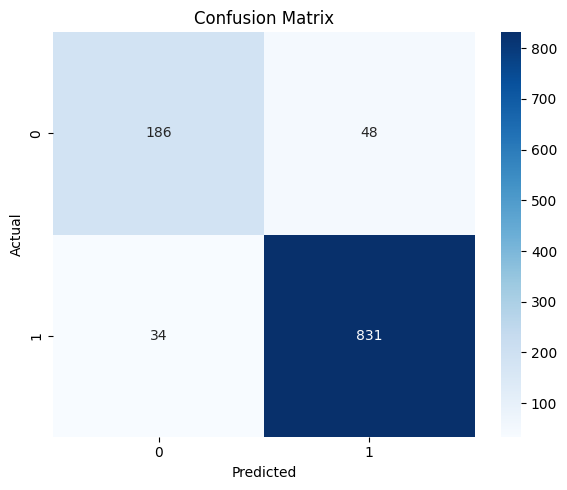

ROC Curve:


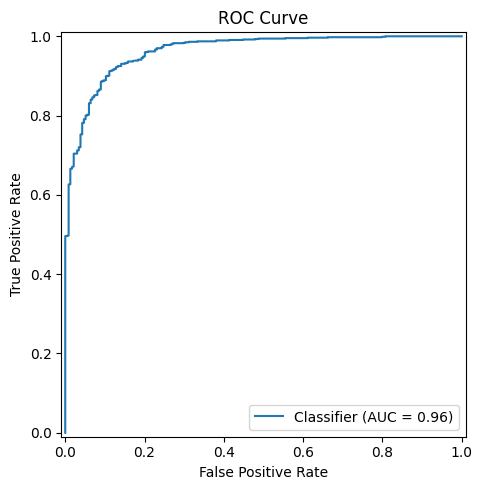

AUPRC Curve:


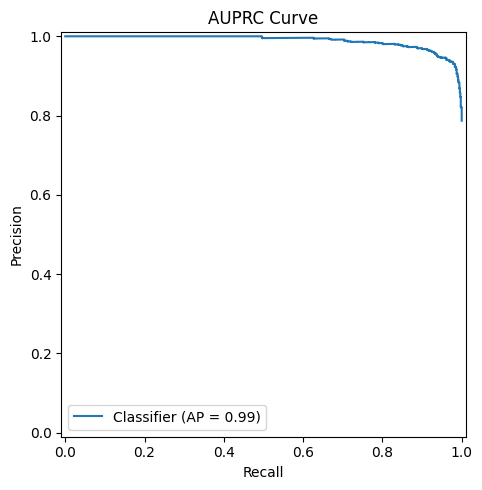

In [82]:
calc_metrics(final_model_et, best_thr=best_thr_et, model_name="et_final")

In [85]:
# Train loss on the full pool the model was trained on
from sklearn.metrics import log_loss
import numpy as np

train_ll_et = log_loss(y_train_full_et,
                       final_model_et.predict_proba(X_train_full_et))
print(f"Log Loss (Train+Val pool): {train_ll_et:.4f}")


Log Loss (Train+Val pool): 0.1015


In [87]:
save_model(final_model_et, "extratree_bioactivity_model", model_path="extratree")


Model saved to saved_model/extratree/


#### CNN 

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [17]:
# Calculate class weights for imbalance
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
class_weights = torch.tensor([1.0, neg_count / pos_count], dtype=torch.float32).to(device)
print(f"Class imbalance ratio: {neg_count / pos_count:.2f}:1")

Class imbalance ratio: 0.24:1


In [18]:
class CNN1D(nn.Module):
    """
    1D CNN for tabular data classification
    """
    def __init__(self, input_size, trial):
        super(CNN1D, self).__init__()
        
        # Hyperparameters from Optuna
        n_conv_layers = trial.suggest_int("n_conv_layers", 1, 3)
        n_fc_layers = trial.suggest_int("n_fc_layers", 1, 3)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5, log=True)
        
        # Build convolutional layers
        conv_layers = []
        in_channels = 1
        current_size = input_size
        
        for i in range(n_conv_layers):
            out_channels = trial.suggest_int(f"conv_{i}_out_channels", 32, 128, step=32)
            kernel_size = trial.suggest_int(f"conv_{i}_kernel_size", 3, 5, step=2)
            
            conv_layers.append(nn.Conv1d(in_channels, out_channels, kernel_size, padding=kernel_size//2))
            conv_layers.append(nn.BatchNorm1d(out_channels))
            conv_layers.append(nn.ReLU())
            conv_layers.append(nn.Dropout(dropout_rate))
            
            # Optional pooling
            if trial.suggest_categorical(f"conv_{i}_pooling", [True, False]):
                pool_size = trial.suggest_int(f"conv_{i}_pool_size", 2, 3)
                conv_layers.append(nn.MaxPool1d(pool_size))
                current_size = current_size // pool_size
            
            in_channels = out_channels
        
        self.conv_block = nn.Sequential(*conv_layers)
        
        # Calculate flattened size
        flattened_size = out_channels * current_size
        
        # Build fully connected layers
        fc_layers = []
        prev_size = flattened_size
        
        for i in range(n_fc_layers):
            fc_size = trial.suggest_int(f"fc_{i}_size", 64, 256, log=True)
            fc_layers.append(nn.Linear(prev_size, fc_size))
            fc_layers.append(nn.ReLU())
            fc_layers.append(nn.Dropout(dropout_rate))
            prev_size = fc_size
        
        # Output layer
        fc_layers.append(nn.Linear(prev_size, 2))
        
        self.fc_block = nn.Sequential(*fc_layers)
    
    def forward(self, x):
        x = x.unsqueeze(1)  # Add channel dimension: (batch, features) -> (batch, 1, features)
        x = self.conv_block(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc_block(x)
        return x

In [19]:
class CNN2D(nn.Module):
    """
    2D CNN for image-like data classification
    Assumes input is reshaped to (batch, channels, height, width)
    """
    def __init__(self, input_channels, input_height, input_width, trial):
        super(CNN2D, self).__init__()
        
        # Hyperparameters from Optuna
        n_conv_layers = trial.suggest_int("n_conv_layers", 2, 5)
        n_fc_layers = trial.suggest_int("n_fc_layers", 1, 3)
        dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5, step=0.1)
        
        # Build convolutional layers
        conv_layers = []
        in_channels = input_channels
        current_h, current_w = input_height, input_width
        
        for i in range(n_conv_layers):
            out_channels = trial.suggest_int(f"conv_{i}_out_channels", 16, 128, step=16)
            kernel_size = trial.suggest_int(f"conv_{i}_kernel_size", 3, 7, step=2)
            
            conv_layers.append(nn.Conv2d(in_channels, out_channels, kernel_size, padding=kernel_size//2))
            conv_layers.append(nn.BatchNorm2d(out_channels))
            conv_layers.append(nn.ReLU())
            conv_layers.append(nn.Dropout2d(dropout_rate))
            
            # Pooling
            if trial.suggest_categorical(f"conv_{i}_pooling", [True, False]):
                pool_size = trial.suggest_int(f"conv_{i}_pool_size", 2, 3)
                conv_layers.append(nn.MaxPool2d(pool_size))
                current_h = current_h // pool_size
                current_w = current_w // pool_size
            
            in_channels = out_channels
        
        self.conv_block = nn.Sequential(*conv_layers)
        
        # Calculate flattened size
        flattened_size = out_channels * current_h * current_w
        
        # Build fully connected layers
        fc_layers = []
        prev_size = flattened_size
        
        for i in range(n_fc_layers):
            fc_size = trial.suggest_int(f"fc_{i}_size", 64, 512, step=64)
            fc_layers.append(nn.Linear(prev_size, fc_size))
            fc_layers.append(nn.ReLU())
            fc_layers.append(nn.Dropout(dropout_rate))
            prev_size = fc_size
        
        # Output layer
        fc_layers.append(nn.Linear(prev_size, 2))
        
        self.fc_block = nn.Sequential(*fc_layers)
    
    def forward(self, x):
        x = self.conv_block(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc_block(x)
        return x

In [23]:

def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    
    for batch_X, batch_y in dataloader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    
    return total_loss / len(dataloader)


def evaluate(model, dataloader, device):
    """Evaluate model"""
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for batch_X, batch_y in dataloader:
            batch_X = batch_X.to(device)
            outputs = model(batch_X)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)
            
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch_y.numpy())
    
    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


In [20]:
def objective_1d(trial):
    """
    Objective function for 1D CNN (for tabular data)
    """
    
    # Prepare data
    X_train_tensor = torch.FloatTensor(X_train.values if hasattr(X_train, 'values') else X_train)
    y_train_tensor = torch.LongTensor(y_train.values if hasattr(y_train, 'values') else y_train)
    X_val_tensor = torch.FloatTensor(X_val.values if hasattr(X_val, 'values') else X_val)
    y_val_tensor = torch.LongTensor(y_val.values if hasattr(y_val, 'values') else y_val)
    X_test_tensor = torch.FloatTensor(X_test.values if hasattr(X_test, 'values') else X_test)
    y_test_tensor = torch.LongTensor(y_test.values if hasattr(y_test, 'values') else y_test)
    
    # Hyperparameters
    batch_size = trial.suggest_categorical("batch_size", [32, 64])
    learning_rate = trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    n_epochs = 30
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "AdamW", "RMSprop"])
    
    # Create dataloaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # Create model
    input_size = X_train_tensor.shape[1]
    model = CNN1D(input_size, trial).to(device)
    
    # Loss function with class weights
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    
    
    # Optimizer
    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    elif optimizer_name == "AdamW":
        optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    else:  # RMSprop
        optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    
    # Learning rate scheduler
    use_scheduler = trial.suggest_categorical("use_scheduler", [True, False])
    if use_scheduler:
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
    
    # Training loop
    best_auc = 0
    patience_counter = 0
    early_stopping_patience = 10
    
    for epoch in range(n_epochs):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Evaluate
        y_true, y_pred, y_prob = evaluate(model, val_loader, device)
        auc = roc_auc_score(y_true, y_prob)
        
        # Learning rate scheduling
        if use_scheduler:
            scheduler.step(train_loss)
        
        # Early stopping
        if auc > best_auc:
            best_auc = auc
            patience_counter = 0
        else:
            patience_counter += 1
        
        if patience_counter >= early_stopping_patience:
            break
        
        # Report to Optuna for pruning
        trial.report(auc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    return best_auc

##### 1d cnn

In [24]:
# Run optimization
import optuna
print("Starting CNN hyperparameter optimization...")
print("="*60)

# Choose which objective to use
study = optuna.create_study(
    direction="minimize",
    study_name="cnn_optimization",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)
)

# Optimize (use objective_1d for tabular data, objective_2d for images)
study.optimize(objective_1d, n_trials=31, show_progress_bar=True)

# Print results
print("\n" + "="*60)
print("OPTIMIZATION RESULTS")
print("="*60)
print(f"Best trial: {study.best_trial.number}")
print(f"Best AUC: {1 - study.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# Train final model with best parameters
print("\n" + "="*60)
print("TRAINING FINAL MODEL")
print("="*60)

best_params = study.best_params

# Recreate best trial for model architecture
best_trial = study.best_trial

# Prepare data
X_train_full=np.vstack([X_train, X_val])
y_train_full=np.concatenate([y_train, y_val])
X_train_tensor = torch.FloatTensor(X_train_full)
y_train_tensor = torch.LongTensor(y_train_full)
X_test_tensor = torch.FloatTensor(X_test.values if hasattr(X_test, 'values') else X_test)
y_test_tensor = torch.LongTensor(y_test.values if hasattr(y_test, 'values') else y_test)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = best_params['batch_size']
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Create final model
input_size = X_train_tensor.shape[1]
final_model = CNN1D(input_size, best_trial).to(device)

# Train final model
criterion = nn.CrossEntropyLoss(weight=class_weights)

if best_params['optimizer'] == "Adam":
    optimizer = optim.Adam(final_model.parameters(), lr=best_params['learning_rate'], 
                          weight_decay=best_params['weight_decay'])
elif best_params['optimizer'] == "AdamW":
    optimizer = optim.AdamW(final_model.parameters(), lr=best_params['learning_rate'], 
                           weight_decay=best_params['weight_decay'])
else:
    optimizer = optim.RMSprop(final_model.parameters(), lr=best_params['learning_rate'],  
                         weight_decay=best_params['weight_decay'])

for epoch in range(30):
    train_loss = train_epoch(final_model, train_loader, criterion, optimizer, device)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/30, Loss: {train_loss:.4f}")

# Final evaluation
y_true, y_pred, y_prob = evaluate(final_model, test_loader, device)

print(f"\nFinal Model Performance:")
print(f"  Accuracy: {accuracy_score(y_true, y_pred):.4f}")
print(f"  ROC-AUC: {roc_auc_score(y_true, y_prob):.4f}")
print(f"  F1 Score: {f1_score(y_true, y_pred):.4f}")

from sklearn.metrics import classification_report, confusion_matrix
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))
print(f"\nClassification Report:")
print(classification_report(y_true, y_pred))

# Save model
torch.save(final_model.state_dict(), 'best_cnn_model.pth')
print("\nModel saved as 'best_cnn_model.pth'")

[I 2025-11-21 09:05:26,148] A new study created in memory with name: cnn_optimization


Starting CNN hyperparameter optimization...


Best trial: 0. Best value: 0.921518:   3%|▎         | 1/31 [00:10<05:22, 10.76s/it]

[I 2025-11-21 09:05:36,904] Trial 0 finished with value: 0.9215184645966906 and parameters: {'batch_size': 64, 'learning_rate': 0.000291063591313307, 'weight_decay': 6.251373574521755e-05, 'optimizer': 'Adam', 'n_conv_layers': 3, 'n_fc_layers': 2, 'dropout_rate': 0.31255143181676115, 'conv_0_out_channels': 32, 'conv_0_kernel_size': 5, 'conv_0_pooling': True, 'conv_0_pool_size': 2, 'conv_1_out_channels': 32, 'conv_1_kernel_size': 3, 'conv_1_pooling': True, 'conv_1_pool_size': 2, 'conv_2_out_channels': 96, 'conv_2_kernel_size': 3, 'conv_2_pooling': False, 'fc_0_size': 120, 'fc_1_size': 190, 'use_scheduler': False}. Best is trial 0 with value: 0.9215184645966906.


Best trial: 1. Best value: 0.920731:   6%|▋         | 2/31 [00:24<05:57, 12.32s/it]

...

[I 2025-11-21 09:11:25,937] Trial 28 finished with value: 0.914179522356301 and parameters: {'batch_size': 64, 'learning_rate': 0.00010102955572424535, 'weight_decay': 0.0008432732955441743, 'optimizer': 'Adam', 'n_conv_layers': 3, 'n_fc_layers': 1, 'dropout_rate': 0.4996431941641488, 'conv_0_out_channels': 128, 'conv_0_kernel_size': 3, 'conv_0_pooling': True, 'conv_0_pool_size': 3, 'conv_1_out_channels': 64, 'conv_1_kernel_size': 3, 'conv_1_pooling': False, 'conv_2_out_channels': 32, 'conv_2_kernel_size': 3, 'conv_2_pooling': False, 'fc_0_size': 138, 'use_scheduler': False}. Best is trial 26 with value: 0.8974227958675141.


Best trial: 26. Best value: 0.897423:  97%|█████████▋| 30/31 [06:09<00:11, 11.06s/it]

[I 2025-11-21 09:11:35,524] Trial 29 finished with value: 0.9194011255144608 and parameters: {'batch_size': 64, 'learning_rate': 0.0001138953480076205, 'weight_decay': 0.000850088685083961, 'optimizer': 'Adam', 'n_conv_layers': 3, 'n_fc_layers': 1, 'dropout_rate': 0.48164086960695207, 'conv_0_out_channels': 128, 'conv_0_kernel_size': 5, 'conv_0_pooling': True, 'conv_0_pool_size': 3, 'conv_1_out_channels': 64, 'conv_1_kernel_size': 3, 'conv_1_pooling': False, 'conv_2_out_channels': 32, 'conv_2_kernel_size': 3, 'conv_2_pooling': False, 'fc_0_size': 112, 'use_scheduler': False}. Best is trial 26 with value: 0.8974227958675141.


Best trial: 26. Best value: 0.897423: 100%|██████████| 31/31 [06:18<00:00, 12.22s/it]



[I 2025-11-21 09:11:45,081] Trial 30 finished with value: 0.9192681356216926 and parameters: {'batch_size': 64, 'learning_rate': 8.038437951279324e-05, 'weight_decay': 0.0009898963513775172, 'optimizer': 'Adam', 'n_conv_layers': 3, 'n_fc_layers': 1, 'dropout_rate': 0.4019959147176979, 'conv_0_out_channels': 128, 'conv_0_kernel_size': 3, 'conv_0_pooling': True, 'conv_0_pool_size': 3, 'conv_1_out_channels': 32, 'conv_1_kernel_size': 3, 'conv_1_pooling': False, 'conv_2_out_channels': 32, 'conv_2_kernel_size': 3, 'conv_2_pooling': False, 'fc_0_size': 138, 'use_scheduler': False}. Best is trial 26 with value: 0.8974227958675141.

OPTIMIZATION RESULTS
Best trial: 26
Best AUC: 0.1026

Best hyperparameters:
  batch_size: 64
  learning_rate: 9.154974422549072e-05
  weight_decay: 3.974413799446102e-05
  optimizer: Adam
  n_conv_layers: 3
  n_fc_layers: 1
  dropout_rate: 0.38153498503932975
  conv_0_out_channels: 64
  conv_0_kernel_size: 3
  conv_0_pooling: True
  conv_0_pool_size: 3
  conv_1_out

Accuracy: 0.8519
Balanced Acc.: 0.6190
Precision: 0.8494
Recall: 0.9935
F1 Score: 0.9158
ROC-AUC: 0.9205
MCC: 0.4217
NPV: 0.8980
AUPRC: 0.9753
Specificity: 0.2444
Sensitivity: 0.9935
Informedness: 0.2380
DOR: 49.6294
Brier Score: 0.1129
********************
Confusion Matrix:


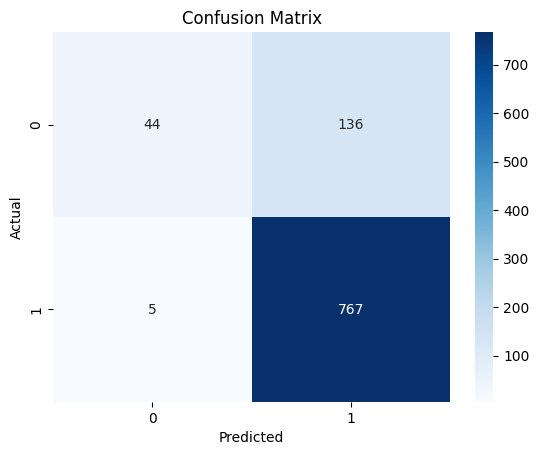

ROC Curve:


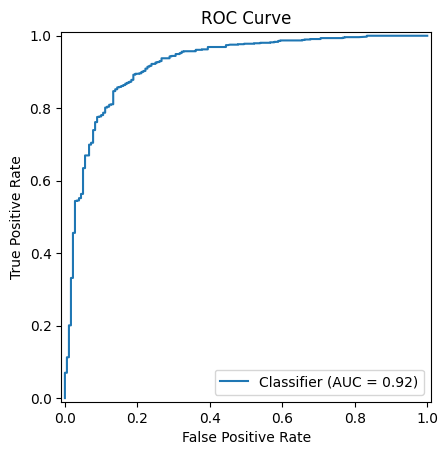

AUPRC Curve:


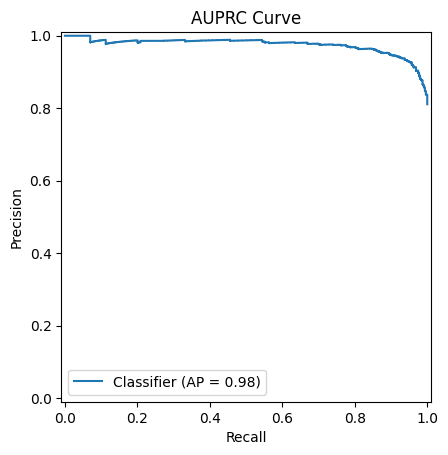

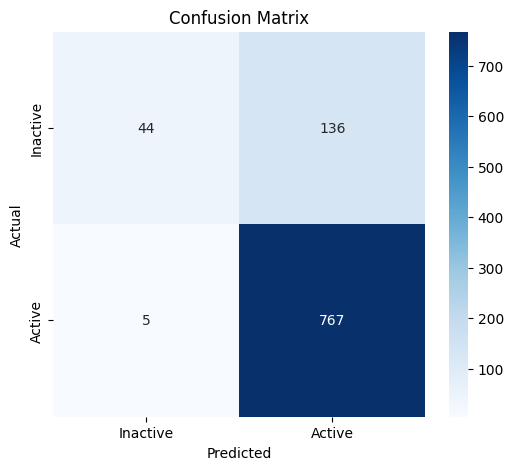

              precision    recall  f1-score   support

           0       0.90      0.24      0.38       180
           1       0.85      0.99      0.92       772

    accuracy                           0.85       952
   macro avg       0.87      0.62      0.65       952
weighted avg       0.86      0.85      0.82       952



In [25]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Robust confusion matrix plot that works for sklearn-like models or the trained PyTorch CNN
import matplotlib.pyplot as plt

# Get predictions and true labels
if hasattr(final_model, "predict") and 'X_test' in globals():
    y_pred_local = final_model.predict(X_test)
    y_true_local = y_test.values if hasattr(y_test, "values") else y_test
elif 'y_pred' in globals() and 'y_true' in globals() and 'y_pred' in globals():
    y_pred_local = y_pred
    y_true_local = y_true
    y_prob_local = y_prob
else:
    # Fall back to using the PyTorch model and test_loader
    final_model.eval()
    preds, trues, probs = [], [], []
    with torch.no_grad():
        for bx, by in test_loader:
            bx = bx.to(device)
            out = final_model(bx)
            pred = torch.argmax(out, dim=1).cpu().numpy()
            prob = torch.softmax(out, dim=1)[:, 1]
            preds.append(pred)
            trues.append(by.numpy())
            probs.append(prob)
    y_pred_local = np.concatenate(preds)
    y_true_local = np.concatenate(trues)
    y_prob_local = np.concatenate(probs)
# Plot
accuracy = accuracy_score(y_true_local, y_pred_local)
balanced_acc = balanced_accuracy_score(y_true_local, y_pred_local)
precision = precision_score(y_true_local, y_pred_local)
recall = recall_score(y_true_local, y_pred_local)  # This is also Sensitivity
f1 = f1_score(y_true_local, y_pred_local)
roc_auc = roc_auc_score(y_true_local, y_prob_local)
mcc = matthews_corrcoef(y_true_local, y_pred_local)
auprc = average_precision_score(y_true_local, y_prob_local)  # Area Under Precision-Recall Curve
kappa = cohen_kappa_score(y_true_local, y_pred_local, weights='quadratic')

# For Specificity: Derive from confusion matrix
cm = confusion_matrix(y_true_local, y_pred_local)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
npv = tn / (tn + fn) 
sensitivity = recall  # Same as recall
informedness = sensitivity + specificity - 1

dor = (tp * tn) / (fn * fp) if fp != 0 and fn != 0 else float('inf')

brier = brier_score_loss(y_true_local, y_prob_local)

# Step 3: Print or store results (e.g., to fill your table)
print(f"Accuracy: {accuracy:.4f}")
print(f"Balanced Acc.: {balanced_acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"MCC: {mcc:.4f}")
print(f"NPV: {npv:.4f}")
print(f"AUPRC: {auprc:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print("Informedness: {:.4f}".format(informedness))
print(f"DOR: {dor:.4f}")
print(f"Brier Score: {brier:.4f}")

print("********************")
print("Confusion Matrix:")
plot_confusion_matrix(y_true_local, y_pred_local)

print("ROC Curve:")
plot_roc_curve(y_true_local, y_prob_local)

print("AUPRC Curve:")
plot_auprc_curve(y_true_local, y_prob_local)

cm = confusion_matrix(y_true_local, y_pred_local)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Inactive','Active'], yticklabels=['Inactive','Active'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Print classification report
print(classification_report(y_true_local, y_pred_local))

##### 2d

In [ ]:
# # Run optimization
# print("Starting CNN hyperparameter optimization...")
# print("="*60)

# # Choose which objective to use
# study = optuna.create_study(
#     direction="minimize",
#     study_name="cnn_optimization",
#     sampler=optuna.samplers.TPESampler(seed=42),
#     pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10)
# )

# # Optimize (use objective_1d for tabular data, objective_2d for images)
# study.optimize(objective_2d, n_trials=50, show_progress_bar=True)

# # Print results
# print("\n" + "="*60)
# print("OPTIMIZATION RESULTS")
# print("="*60)
# print(f"Best trial: {study.best_trial.number}")
# print(f"Best AUC: {1 - study.best_value:.4f}")
# print(f"\nBest hyperparameters:")
# for key, value in study.best_params.items():
#     print(f"  {key}: {value}")

# # Train final model with best parameters
# print("\n" + "="*60)
# print("TRAINING FINAL MODEL")
# print("="*60)

# best_params = study.best_params

# # Recreate best trial for model architecture
# best_trial = study.best_trial

# # Prepare data
# X_train_tensor = torch.FloatTensor(X_train.values if hasattr(X_train, 'values') else X_train)
# y_train_tensor = torch.LongTensor(y_train.values if hasattr(y_train, 'values') else y_train)
# X_test_tensor = torch.FloatTensor(X_test.values if hasattr(X_test, 'values') else X_test)
# y_test_tensor = torch.LongTensor(y_test.values if hasattr(y_test, 'values') else y_test)

# train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
# test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# batch_size = best_params['batch_size']
# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# # Create final model
# input_size = X_train_tensor.shape[1]
# final_model = CNN1D(input_size, best_trial).to(device)

# # Train final model
# criterion = nn.CrossEntropyLoss(weight=class_weights if best_params['use_class_weights'] else None)

# if best_params['optimizer'] == "Adam":
#     optimizer = optim.Adam(final_model.parameters(), lr=best_params['learning_rate'], 
#                           weight_decay=best_params['weight_decay'])
# elif best_params['optimizer'] == "AdamW":
#     optimizer = optim.AdamW(final_model.parameters(), lr=best_params['learning_rate'], 
#                            weight_decay=best_params['weight_decay'])
# else:
#     optimizer = optim.SGD(final_model.parameters(), lr=best_params['learning_rate'], 
#                          momentum=best_params.get('momentum', 0.9), 
#                          weight_decay=best_params['weight_decay'])

# for epoch in range(best_params['n_epochs']):
#     train_loss = train_epoch(final_model, train_loader, criterion, optimizer, device)
#     if (epoch + 1) % 10 == 0:
#         print(f"Epoch {epoch+1}/{best_params['n_epochs']}, Loss: {train_loss:.4f}")

# # Final evaluation
# y_true, y_pred, y_prob = evaluate(final_model, test_loader, device)

# print(f"\nFinal Model Performance:")
# print(f"  Accuracy: {accuracy_score(y_true, y_pred):.4f}")
# print(f"  ROC-AUC: {roc_auc_score(y_true, y_prob):.4f}")
# print(f"  F1 Score: {f1_score(y_true, y_pred):.4f}")

# from sklearn.metrics import classification_report, confusion_matrix
# print(f"\nConfusion Matrix:")
# print(confusion_matrix(y_true, y_pred))
# print(f"\nClassification Report:")
# print(classification_report(y_true, y_pred))

# # Save model
# torch.save(final_model.state_dict(), 'best_cnn_model_2d.pth')
# print("\nModel saved as 'best_cnn_model_2d.pth'")

In [ ]:
# from sklearn.metrics import confusion_matrix, classification_report
# import seaborn as sns

# # Robust confusion matrix plot that works for sklearn-like models or the trained PyTorch CNN
# import matplotlib.pyplot as plt

# # Get predictions and true labels
# if hasattr(final_model, "predict") and 'X_test' in globals():
#     y_pred_local = final_model.predict(X_test)
#     y_true_local = y_test.values if hasattr(y_test, "values") else y_test
# elif 'y_pred' in globals() and 'y_true' in globals() and 'y_pred' in globals():
#     y_pred_local = y_pred
#     y_true_local = y_true
#     y_prob_local = y_prob
# else:
#     # Fall back to using the PyTorch model and test_loader
#     final_model.eval()
#     preds, trues, probs = [], [], []
#     with torch.no_grad():
#         for bx, by in test_loader:
#             bx = bx.to(device)
#             out = final_model(bx)
#             pred = torch.argmax(out, dim=1).cpu().numpy()
#             prob = torch.softmax(out, dim=1)[:, 1]
#             preds.append(pred)
#             trues.append(by.numpy())
#             probs.append(prob)
#     y_pred_local = np.concatenate(preds)
#     y_true_local = np.concatenate(trues)
#     y_prob_local = np.concatenate(probs)
# # Plot
# accuracy = accuracy_score(y_true_local, y_pred_local)
# balanced_acc = balanced_accuracy_score(y_true_local, y_pred_local)
# precision = precision_score(y_true_local, y_pred_local)
# recall = recall_score(y_true_local, y_pred_local)  # This is also Sensitivity
# f1 = f1_score(y_true_local, y_pred_local)
# roc_auc = roc_auc_score(y_true_local, y_prob_local)
# mcc = matthews_corrcoef(y_true_local, y_pred_local)
# auprc = average_precision_score(y_true_local, y_prob_local)  # Area Under Precision-Recall Curve

# # For Specificity: Derive from confusion matrix
# cm = confusion_matrix(y_true_local, y_pred_local)
# tn, fp, fn, tp = cm.ravel()
# specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
# sensitivity = recall  # Same as recall

# # Step 3: Print or store results (e.g., to fill your table)
# print(f"Accuracy: {accuracy:.4f}")
# print(f"Balanced Acc.: {balanced_acc:.4f}")
# print(f"Precision: {precision:.4f}")
# print(f"Recall: {recall:.4f}")
# print(f"F1 Score: {f1:.4f}")
# print(f"ROC-AUC: {roc_auc:.4f}")
# print(f"MCC: {mcc:.4f}")
# print(f"Specificity: {specificity:.4f}")
# print(f"Sensitivity: {sensitivity:.4f}")
# print(f"AUPRC: {auprc:.4f}")
# cm = confusion_matrix(y_true_local, y_pred_local)
# plt.figure(figsize=(6,5))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Inactive','Active'], yticklabels=['Inactive','Active'])
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.title('Confusion Matrix')
# plt.show()

# # Print classification report
# print(classification_report(y_true_local, y_pred_local))

 #### SVN 

In [88]:
# ── SVM 5-Fold Stratified CV (imbalance-aware, no Optuna) ────────────────────
import warnings
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, average_precision_score,
    matthews_corrcoef, cohen_kappa_score, brier_score_loss,
    confusion_matrix, precision_recall_curve,
)

warnings.filterwarnings("ignore")

N_CV_SPLITS_SVM = 5

# Inverse-transform descriptor columns back to raw so each fold fits its own scaler
# (SVM is scale-sensitive — per-fold StandardScaler prevents data leakage)
X_train_raw_svm = X_train.copy()
X_train_raw_svm[:, DESC_COLS] = scaler.inverse_transform(X_train[:, DESC_COLS])

# Convert y_train to numpy — StratifiedKFold returns positional indices but
# y_train is a pandas Series with non-contiguous original DataFrame labels
y_train_arr_svm = np.asarray(y_train)

print(f"Class imbalance ratio (neg/pos): "
      f"{(y_train_arr_svm==0).sum() / ((y_train_arr_svm==1).sum() + 1e-8):.2f}:1\n")

# ── Imbalance-aware fixed hyperparameters ─────────────────────────────────────
# kernel='rbf'         : effective for high-dimensional mixed feature spaces
# C=1.0                : balanced regularisation; prevents over-fitting minority
# gamma='scale'        : 1 / (n_features * X.var()) — well-calibrated default
# class_weight='balanced': automatically upweights minority class (neg/pos ratio)
# probability=True     : enables predict_proba for OOF threshold tuning & AUC
# tol=1e-4             : standard convergence tolerance
# max_iter=2000        : enough iterations for convergence on imbalanced data
svm_params = dict(
    kernel       = 'rbf',
    C            = 1.0,
    gamma        = 'scale',
    class_weight = 'balanced',
    probability  = True,
    tol          = 1e-4,
    max_iter     = 2000,
    random_state = RANDOM_STATE,
)

print("SVM hyperparameters (imbalance-aware):")
for k, v in svm_params.items():
    print(f"  {k:>22} = {v}")

# ── 5-Fold CV loop ────────────────────────────────────────────────────────────
cv_svm        = StratifiedKFold(n_splits=N_CV_SPLITS_SVM, shuffle=True, random_state=RANDOM_STATE)
oof_probs_svm = np.zeros(len(y_train_arr_svm))
fold_data_svm = []

FOLD_COLS_SVM = ['Acc', 'Bal.Acc', 'Prec', 'Rec', 'F1', 'AUC', 'AUPRC', 'MCC', 'Spec', 'Kappa', 'Brier']
hdr_line_svm  = f"{'Fold':>6}  " + "  ".join(f"{c:>8}" for c in FOLD_COLS_SVM)
print(f"\n{hdr_line_svm}")
print("-" * len(hdr_line_svm))

for fold_idx, (tr_idx, val_idx) in enumerate(cv_svm.split(X_train_raw_svm, y_train_arr_svm)):
    X_tr, X_vf = X_train_raw_svm[tr_idx].copy(), X_train_raw_svm[val_idx].copy()
    y_tr, y_vf = y_train_arr_svm[tr_idx], y_train_arr_svm[val_idx]

    # Per-fold StandardScaler on descriptor columns (SVM is scale-sensitive)
    fs = StandardScaler()
    X_tr[:, DESC_COLS] = fs.fit_transform(X_tr[:, DESC_COLS])
    X_vf[:, DESC_COLS] = fs.transform(X_vf[:, DESC_COLS])

    model_svm_fold = SVC(**svm_params)
    model_svm_fold.fit(X_tr, y_tr)

    probs = model_svm_fold.predict_proba(X_vf)[:, 1]
    preds = (probs >= 0.5).astype(int)
    oof_probs_svm[val_idx] = probs

    tn, fp, fn, tp = confusion_matrix(y_vf, preds).ravel()
    spec = tn / (tn + fp + 1e-12)
    npv  = tn / (tn + fn + 1e-12)

    m = {
        'Acc':     accuracy_score(y_vf, preds),
        'Bal.Acc': balanced_accuracy_score(y_vf, preds),
        'Prec':    precision_score(y_vf, preds, zero_division=0),
        'Rec':     recall_score(y_vf, preds, zero_division=0),
        'F1':      f1_score(y_vf, preds, zero_division=0),
        'AUC':     roc_auc_score(y_vf, probs),
        'AUPRC':   average_precision_score(y_vf, probs),
        'MCC':     matthews_corrcoef(y_vf, preds),
        'Spec':    spec,
        'Kappa':   cohen_kappa_score(y_vf, preds),
        'Brier':   brier_score_loss(y_vf, probs),
        'NPV':     npv,
    }
    fold_data_svm.append(m)
    row_str = "  ".join(f"{m[c]:>8.4f}" for c in FOLD_COLS_SVM)
    print(f"{fold_idx + 1:>6}  {row_str}")

print("=" * len(hdr_line_svm))

# ── Per-metric summary ────────────────────────────────────────────────────────
SUMMARY_MAP_SVM = {
    'Accuracy':     'Acc',
    'Balanced Acc': 'Bal.Acc',
    'Precision':    'Prec',
    'Recall':       'Rec',
    'F1':           'F1',
    'ROC-AUC':      'AUC',
    'AUPRC':        'AUPRC',
    'MCC':          'MCC',
    'Sensitivity':  'Rec',
    'Specificity':  'Spec',
    'NPV':          'NPV',
    "Cohen's k":    'Kappa',
    'Brier':        'Brier',
}

def _ci95_svm(arr):
    se = np.std(arr, ddof=1) / np.sqrt(len(arr))
    return np.mean(arr) - 1.96 * se, np.mean(arr) + 1.96 * se

summary_rows_svm = {}
for label, col in SUMMARY_MAP_SVM.items():
    vals = np.array([d[col] for d in fold_data_svm])
    lo, hi = _ci95_svm(vals)
    summary_rows_svm[label] = {
        'Mean +- Std': f"{np.mean(vals):.4f} +- {np.std(vals, ddof=1):.4f}",
        'Min':         f"{np.min(vals):.4f}",
        'Max':         f"{np.max(vals):.4f}",
        '95% CI':      f"[{lo:.4f}, {hi:.4f}]",
    }

summary_df_svm = pd.DataFrame(summary_rows_svm).T
summary_df_svm.index.name = 'Metric'
print(f"\n  Per-Metric Summary\n")
print(summary_df_svm.to_string())

# ── OOF threshold tuning ──────────────────────────────────────────────────────
oof_auc_svm  = roc_auc_score(y_train_arr_svm, oof_probs_svm)
oof_ap_svm   = average_precision_score(y_train_arr_svm, oof_probs_svm)
prec_c, rec_c, thr_c = precision_recall_curve(y_train_arr_svm, oof_probs_svm)
f1s_svm      = 2 * prec_c * rec_c / (prec_c + rec_c + 1e-8)
best_thr_svm = float(thr_c[np.argmax(f1s_svm[:-1])])

print(f"\nOOF ROC-AUC  : {oof_auc_svm:.4f}")
print(f"OOF AUPRC    : {oof_ap_svm:.4f}")
print(f"Optimal thr  : {best_thr_svm:.3f}  (OOF F1-max threshold)")

# ── Paper-ready summary ───────────────────────────────────────────────────────
PAPER_METRICS_SVM = ['Accuracy', 'ROC-AUC', 'F1', 'MCC', 'AUPRC',
                     'Sensitivity', 'Specificity', "Cohen's k", 'Brier']
paper_df_svm = pd.DataFrame(
    {m: [summary_rows_svm[m]['Mean +- Std']] for m in PAPER_METRICS_SVM},
    index=[f'SVM ({N_CV_SPLITS_SVM}-Fold CV)'],
).T
paper_df_svm.index.name = None
print(f"\n  Paper-Ready Summary\n")
print(paper_df_svm.to_string())


Class imbalance ratio (neg/pos): 0.27:1

SVM hyperparameters (imbalance-aware):
                  kernel = rbf
                       C = 1.0
                   gamma = scale
            class_weight = balanced
             probability = True
                     tol = 0.0001
                max_iter = 2000
            random_state = 42

  Fold       Acc   Bal.Acc      Prec       Rec        F1       AUC     AUPRC       MCC      Spec     Kappa     Brier
--------------------------------------------------------------------------------------------------------------------
     1    0.9249    0.8698    0.9409    0.9654    0.9530    0.9499    0.9785    0.7683    0.7742    0.7667    0.0572
     2    0.9181    0.8543    0.9330    0.9653    0.9489    0.9520    0.9841    0.7462    0.7433    0.7434    0.0616
     3    0.9078    0.8459    0.9309    0.9538    0.9422    0.9369    0.9719    0.7167    0.7380    0.7155    0.0676
     4    0.9226    0.8787    0.9470    0.9552    0.9511    0.9617    0.989

In [103]:
# ── Train final SVM on full training set, then evaluate on held-out test set ──
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, average_precision_score,
    matthews_corrcoef, cohen_kappa_score, brier_score_loss,
    confusion_matrix, classification_report,
)

# ── Leakage-free preprocessing ────────────────────────────────────────────────
# Inverse-transform everything back to raw, then fit a fresh scaler on the
# full training set so train and test are consistently scaled.
X_train_raw_svm = X_train.copy()
X_train_raw_svm[:, DESC_COLS] = scaler.inverse_transform(X_train[:, DESC_COLS])

X_test_raw_svm = X_test.copy()
X_test_raw_svm[:, DESC_COLS] = scaler.inverse_transform(X_test[:, DESC_COLS])

final_scaler_svm = StandardScaler()
X_train_full_svm = X_train_raw_svm.copy()
X_train_full_svm[:, DESC_COLS] = final_scaler_svm.fit_transform(X_train_raw_svm[:, DESC_COLS])

X_test_final_svm = X_test_raw_svm.copy()
X_test_final_svm[:, DESC_COLS] = final_scaler_svm.transform(X_test_raw_svm[:, DESC_COLS])

y_train_full_svm = np.asarray(y_train)

final_model_svm = SVC(**svm_params)
final_model_svm.fit(X_train_full_svm, y_train_full_svm)
print(f"Final SVM trained  |  threshold = {best_thr_svm:.3f}\n")

y_prob_svm = final_model_svm.predict_proba(X_test_final_svm)[:, 1]
y_true_svm = np.asarray(y_test)

def _eval_svm(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return y_pred, {
        'Accuracy':     accuracy_score(y_true, y_pred),
        'Balanced Acc': balanced_accuracy_score(y_true, y_pred),
        'Precision':    precision_score(y_true, y_pred, zero_division=0),
        'Recall':       recall_score(y_true, y_pred, zero_division=0),
        'F1':           f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC':      roc_auc_score(y_true, y_prob),
        'AUPRC':        average_precision_score(y_true, y_prob),
        'MCC':          matthews_corrcoef(y_true, y_pred),
        'Specificity':  tn / (tn + fp + 1e-12),
        'NPV':          tn / (tn + fn + 1e-12),
        "Cohen's k":    cohen_kappa_score(y_true, y_pred),
        'Brier':        brier_score_loss(y_true, y_prob),
    }

y_pred_default_svm, m_default_svm = _eval_svm(y_true_svm, y_prob_svm, 0.50)
y_pred_tuned_svm,   m_tuned_svm   = _eval_svm(y_true_svm, y_prob_svm, best_thr_svm)

cmp_df_svm = pd.DataFrame({
    #'thr=0.500 (default)':                  m_default_svm,
    f'thr={best_thr_svm:.3f} (OOF-tuned)': m_tuned_svm,
})
print("  Test Set Comparison\n")
print(cmp_df_svm.to_string(float_format=lambda x: f"{x:.4f}"))

print(f"\n  Classification Report  (threshold = {best_thr_svm:.3f})\n")
print(classification_report(y_true_svm, y_pred_tuned_svm, target_names=['Inactive', 'Active']))


Final SVM trained  |  threshold = 0.564

  Test Set Comparison

              thr=0.564 (OOF-tuned)
Accuracy                     0.9236
Balanced Acc                 0.8844
Precision                    0.9504
Recall                       0.9526
F1                           0.9515
ROC-AUC                      0.9571
AUPRC                        0.9865
MCC                          0.7713
Specificity                  0.8162
NPV                          0.8233
Cohen's k                    0.7712
Brier                        0.0596

  Classification Report  (threshold = 0.564)

              precision    recall  f1-score   support

    Inactive       0.82      0.82      0.82       234
      Active       0.95      0.95      0.95       865

    accuracy                           0.92      1099
   macro avg       0.89      0.88      0.89      1099
weighted avg       0.92      0.92      0.92      1099



Accuracy: 0.9236
Balanced Acc.: 0.8844
Cohen's Kappa: 0.7712
Precision: 0.9504
Recall: 0.9526
F1 Score: 0.9515
ROC-AUC: 0.9571
AUPRC: 0.9865
MCC: 0.7713
NPV: 0.8233
Specificity: 0.8162
Sensitivity: 0.9526
Informedness: 0.7688
DOR: 89.2706
Brier Score: 0.0596
********************
Confusion Matrix:


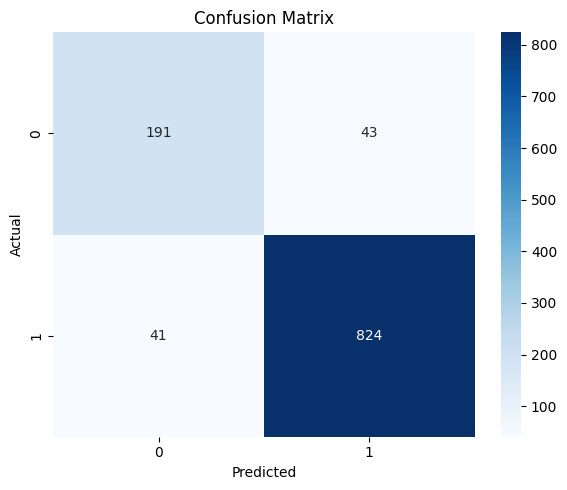

ROC Curve:


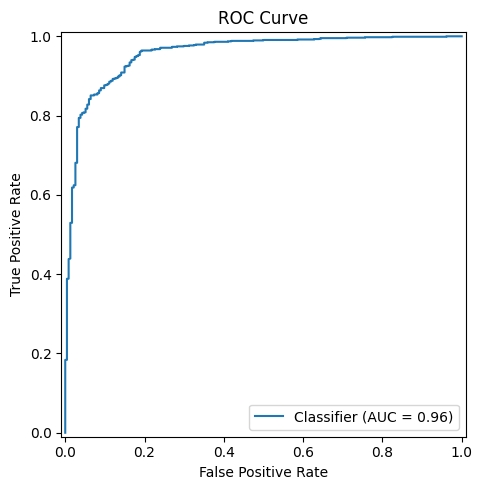

AUPRC Curve:


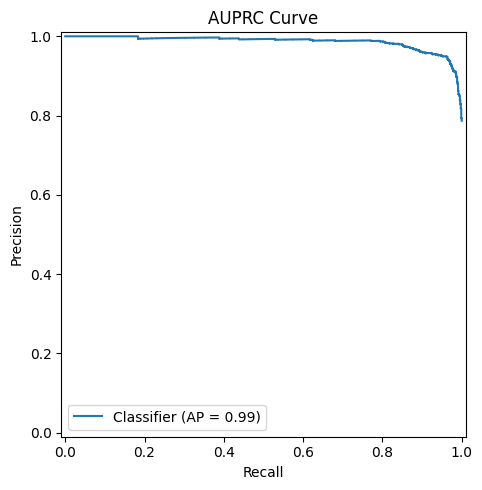

In [90]:
calc_metrics(final_model_svm, best_thr=best_thr_svm, model_name="svm_final")

In [106]:
save_model(final_model_svm, "svm_bioactivity_model", "svm")

Model saved to saved_model/svm/


#### KNN 

In [99]:
# ── KNN 5-Fold Stratified CV (imbalance-aware, no Optuna) ────────────────────
import warnings
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, average_precision_score,
    matthews_corrcoef, cohen_kappa_score, brier_score_loss,
    confusion_matrix, precision_recall_curve,
)

warnings.filterwarnings("ignore")

N_CV_SPLITS_KNN = 5

# Inverse-transform descriptor columns back to raw so each fold fits its own scaler
# (KNN is distance-based — feature scaling is critical)
X_train_raw_knn = X_train.copy()
X_train_raw_knn[:, DESC_COLS] = scaler.inverse_transform(X_train[:, DESC_COLS])

# Convert y_train to numpy — StratifiedKFold returns positional indices but
# y_train is a pandas Series with non-contiguous original DataFrame labels
y_train_arr_knn = np.asarray(y_train)

print(f"Class imbalance ratio (neg/pos): "
      f"{(y_train_arr_knn==0).sum() / ((y_train_arr_knn==1).sum() + 1e-8):.2f}:1\n")

# ── Imbalance-aware fixed hyperparameters ─────────────────────────────────────
# n_neighbors=11  : odd to avoid ties; larger k → smoother boundary, more
#                   robust to minority-class noise
# weights='distance': closer neighbours contribute more — active compounds tend
#                   to cluster, so this naturally upweights the minority class
# metric='euclidean': standard L2 distance; effective after scaling
# algorithm='auto' : sklearn selects best structure (ball_tree/kd_tree/brute)
knn_params = dict(
    n_neighbors = 11,
    weights     = 'distance',
    metric      = 'euclidean',
    algorithm   = 'auto',
    leaf_size   = 30,
    n_jobs      = -1,
)

print("KNN hyperparameters (imbalance-aware):")
for k, v in knn_params.items():
    print(f"  {k:>22} = {v}")

# ── 5-Fold CV loop ────────────────────────────────────────────────────────────
cv_knn        = StratifiedKFold(n_splits=N_CV_SPLITS_KNN, shuffle=True, random_state=RANDOM_STATE)
oof_probs_knn = np.zeros(len(y_train_arr_knn))
fold_data_knn = []

FOLD_COLS_KNN = ['Acc', 'Bal.Acc', 'Prec', 'Rec', 'F1', 'AUC', 'AUPRC', 'MCC', 'Spec', 'Kappa', 'Brier']
hdr_line_knn  = f"{'Fold':>6}  " + "  ".join(f"{c:>8}" for c in FOLD_COLS_KNN)
print(f"\n{hdr_line_knn}")
print("-" * len(hdr_line_knn))

for fold_idx, (tr_idx, val_idx) in enumerate(cv_knn.split(X_train_raw_knn, y_train_arr_knn)):
    X_tr, X_vf = X_train_raw_knn[tr_idx].copy(), X_train_raw_knn[val_idx].copy()
    y_tr, y_vf = y_train_arr_knn[tr_idx], y_train_arr_knn[val_idx]

    # Per-fold StandardScaler on descriptor columns (KNN is scale-sensitive)
    fs = StandardScaler()
    X_tr[:, DESC_COLS] = fs.fit_transform(X_tr[:, DESC_COLS])
    X_vf[:, DESC_COLS] = fs.transform(X_vf[:, DESC_COLS])

    model_knn_fold = KNeighborsClassifier(**knn_params)
    model_knn_fold.fit(X_tr, y_tr)

    probs = model_knn_fold.predict_proba(X_vf)[:, 1]
    preds = (probs >= 0.5).astype(int)
    oof_probs_knn[val_idx] = probs

    tn, fp, fn, tp = confusion_matrix(y_vf, preds).ravel()
    spec = tn / (tn + fp + 1e-12)
    npv  = tn / (tn + fn + 1e-12)

    m = {
        'Acc':     accuracy_score(y_vf, preds),
        'Bal.Acc': balanced_accuracy_score(y_vf, preds),
        'Prec':    precision_score(y_vf, preds, zero_division=0),
        'Rec':     recall_score(y_vf, preds, zero_division=0),
        'F1':      f1_score(y_vf, preds, zero_division=0),
        'AUC':     roc_auc_score(y_vf, probs),
        'AUPRC':   average_precision_score(y_vf, probs),
        'MCC':     matthews_corrcoef(y_vf, preds),
        'Spec':    spec,
        'Kappa':   cohen_kappa_score(y_vf, preds),
        'Brier':   brier_score_loss(y_vf, probs),
        'NPV':     npv,
    }
    fold_data_knn.append(m)
    row_str = "  ".join(f"{m[c]:>8.4f}" for c in FOLD_COLS_KNN)
    print(f"{fold_idx + 1:>6}  {row_str}")

print("=" * len(hdr_line_knn))

# ── Per-metric summary ────────────────────────────────────────────────────────
SUMMARY_MAP_KNN = {
    'Accuracy':     'Acc',
    'Balanced Acc': 'Bal.Acc',
    'Precision':    'Prec',
    'Recall':       'Rec',
    'F1':           'F1',
    'ROC-AUC':      'AUC',
    'AUPRC':        'AUPRC',
    'MCC':          'MCC',
    'Sensitivity':  'Rec',
    'Specificity':  'Spec',
    'NPV':          'NPV',
    "Cohen's k":    'Kappa',
    'Brier':        'Brier',
}

def _ci95_knn(arr):
    se = np.std(arr, ddof=1) / np.sqrt(len(arr))
    return np.mean(arr) - 1.96 * se, np.mean(arr) + 1.96 * se

summary_rows_knn = {}
for label, col in SUMMARY_MAP_KNN.items():
    vals = np.array([d[col] for d in fold_data_knn])
    lo, hi = _ci95_knn(vals)
    summary_rows_knn[label] = {
        'Mean +- Std': f"{np.mean(vals):.4f} +- {np.std(vals, ddof=1):.4f}",
        'Min':         f"{np.min(vals):.4f}",
        'Max':         f"{np.max(vals):.4f}",
        '95% CI':      f"[{lo:.4f}, {hi:.4f}]",
    }

summary_df_knn = pd.DataFrame(summary_rows_knn).T
summary_df_knn.index.name = 'Metric'
print(f"\n  Per-Metric Summary\n")
print(summary_df_knn.to_string())

# ── OOF threshold tuning ──────────────────────────────────────────────────────
oof_auc_knn  = roc_auc_score(y_train_arr_knn, oof_probs_knn)
oof_ap_knn   = average_precision_score(y_train_arr_knn, oof_probs_knn)
prec_c, rec_c, thr_c = precision_recall_curve(y_train_arr_knn, oof_probs_knn)
f1s_knn      = 2 * prec_c * rec_c / (prec_c + rec_c + 1e-8)
best_thr_knn = float(thr_c[np.argmax(f1s_knn[:-1])])

print(f"\nOOF ROC-AUC  : {oof_auc_knn:.4f}")
print(f"OOF AUPRC    : {oof_ap_knn:.4f}")
print(f"Optimal thr  : {best_thr_knn:.3f}  (OOF F1-max threshold)")

# ── Paper-ready summary ───────────────────────────────────────────────────────
PAPER_METRICS_KNN = ['Accuracy', 'ROC-AUC', 'F1', 'MCC', 'AUPRC',
                     'Sensitivity', 'Specificity', "Cohen's k", 'Brier']
paper_df_knn = pd.DataFrame(
    {m: [summary_rows_knn[m]['Mean +- Std']] for m in PAPER_METRICS_KNN},
    index=[f'KNN ({N_CV_SPLITS_KNN}-Fold CV)'],
).T
paper_df_knn.index.name = None
print(f"\n  Paper-Ready Summary\n")
print(paper_df_knn.to_string())


Class imbalance ratio (neg/pos): 0.27:1

KNN hyperparameters (imbalance-aware):
             n_neighbors = 11
                 weights = distance
                  metric = euclidean
               algorithm = auto
               leaf_size = 30
                  n_jobs = -1

  Fold       Acc   Bal.Acc      Prec       Rec        F1       AUC     AUPRC       MCC      Spec     Kappa     Brier
--------------------------------------------------------------------------------------------------------------------
     1    0.9113    0.8159    0.9128    0.9812    0.9458    0.9141    0.9621    0.7179    0.6505    0.7037    0.0739
     2    0.9033    0.8098    0.9107    0.9725    0.9406    0.9117    0.9599    0.6929    0.6471    0.6822    0.0761
     3    0.8965    0.7938    0.9034    0.9725    0.9367    0.9106    0.9601    0.6689    0.6150    0.6553    0.0776
     4    0.9090    0.8173    0.9135    0.9769    0.9441    0.9476    0.9808    0.7118    0.6578    0.7002    0.0676
     5    0.9226    0.

In [100]:
# ── Train final KNN on full training set, then evaluate on held-out test set ──
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, average_precision_score,
    matthews_corrcoef, cohen_kappa_score, brier_score_loss,
    confusion_matrix, classification_report,
)

# ── Leakage-free preprocessing ────────────────────────────────────────────────
# Inverse-transform everything back to raw, then fit a fresh scaler on the
# full training set so train and test are consistently scaled.
X_train_raw_knn = X_train.copy()
X_train_raw_knn[:, DESC_COLS] = scaler.inverse_transform(X_train[:, DESC_COLS])

X_test_raw_knn = X_test.copy()
X_test_raw_knn[:, DESC_COLS] = scaler.inverse_transform(X_test[:, DESC_COLS])

final_scaler_knn = StandardScaler()
X_train_full_knn = X_train_raw_knn.copy()
X_train_full_knn[:, DESC_COLS] = final_scaler_knn.fit_transform(X_train_raw_knn[:, DESC_COLS])

X_test_final_knn = X_test_raw_knn.copy()
X_test_final_knn[:, DESC_COLS] = final_scaler_knn.transform(X_test_raw_knn[:, DESC_COLS])

y_train_full_knn = np.asarray(y_train)

final_model_knn = KNeighborsClassifier(**knn_params)
final_model_knn.fit(X_train_full_knn, y_train_full_knn)
print(f"Final KNN trained  |  threshold = {best_thr_knn:.3f}\n")

y_prob_knn = final_model_knn.predict_proba(X_test_final_knn)[:, 1]
y_true_knn = np.asarray(y_test)

def _eval_knn(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return y_pred, {
        'Accuracy':     accuracy_score(y_true, y_pred),
        'Balanced Acc': balanced_accuracy_score(y_true, y_pred),
        'Precision':    precision_score(y_true, y_pred, zero_division=0),
        'Recall':       recall_score(y_true, y_pred, zero_division=0),
        'F1':           f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC':      roc_auc_score(y_true, y_prob),
        'AUPRC':        average_precision_score(y_true, y_prob),
        'MCC':          matthews_corrcoef(y_true, y_pred),
        'Specificity':  tn / (tn + fp + 1e-12),
        'NPV':          tn / (tn + fn + 1e-12),
        "Cohen's k":    cohen_kappa_score(y_true, y_pred),
        'Brier':        brier_score_loss(y_true, y_prob),
    }

y_pred_default_knn, m_default_knn = _eval_knn(y_true_knn, y_prob_knn, 0.50)
y_pred_tuned_knn,   m_tuned_knn   = _eval_knn(y_true_knn, y_prob_knn, best_thr_knn)

cmp_df_knn = pd.DataFrame({
    #'thr=0.500 (default)':                  m_default_knn,
    f'thr={best_thr_knn:.3f} (OOF-tuned)': m_tuned_knn,
})
print("  Test Set Comparison\n")
print(cmp_df_knn.to_string(float_format=lambda x: f"{x:.4f}"))

print(f"\n  Classification Report  (threshold = {best_thr_knn:.3f})\n")
print(classification_report(y_true_knn, y_pred_tuned_knn, target_names=['Inactive', 'Active']))


Final KNN trained  |  threshold = 0.626

  Test Set Comparison

              thr=0.626 (OOF-tuned)
Accuracy                     0.9090
Balanced Acc                 0.8502
Precision                    0.9332
Recall                       0.9526
F1                           0.9428
ROC-AUC                      0.9289
AUPRC                        0.9700
MCC                          0.7216
Specificity                  0.7479
NPV                          0.8102
Cohen's k                    0.7207
Brier                        0.0724

  Classification Report  (threshold = 0.626)

              precision    recall  f1-score   support

    Inactive       0.81      0.75      0.78       234
      Active       0.93      0.95      0.94       865

    accuracy                           0.91      1099
   macro avg       0.87      0.85      0.86      1099
weighted avg       0.91      0.91      0.91      1099



Accuracy: 0.9090
Balanced Acc.: 0.8502
Cohen's Kappa: 0.7207
Precision: 0.9332
Recall: 0.9526
F1 Score: 0.9428
ROC-AUC: 0.9289
AUPRC: 0.9700
MCC: 0.7216
NPV: 0.8102
Specificity: 0.7479
Sensitivity: 0.9526
Informedness: 0.7005
DOR: 59.6114
Brier Score: 0.0724
********************
Confusion Matrix:


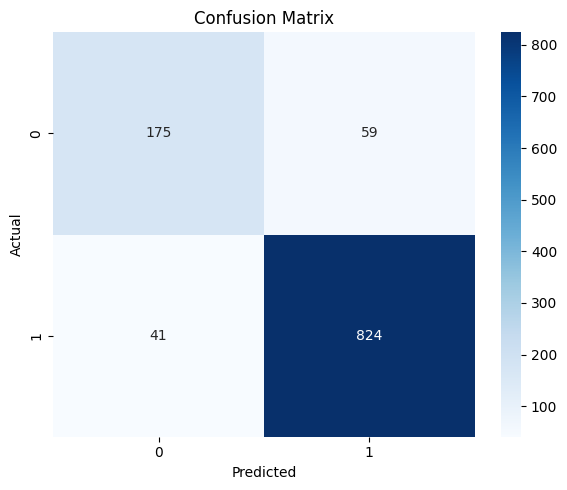

ROC Curve:


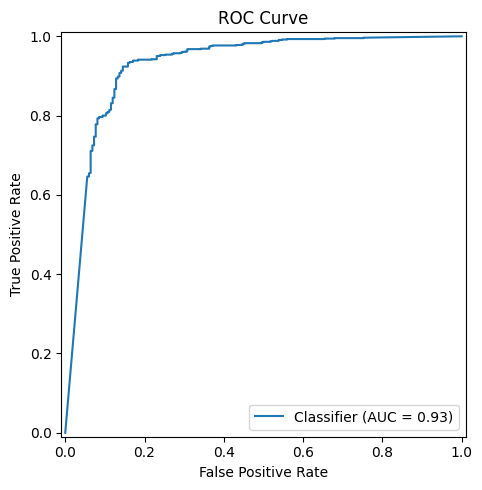

AUPRC Curve:


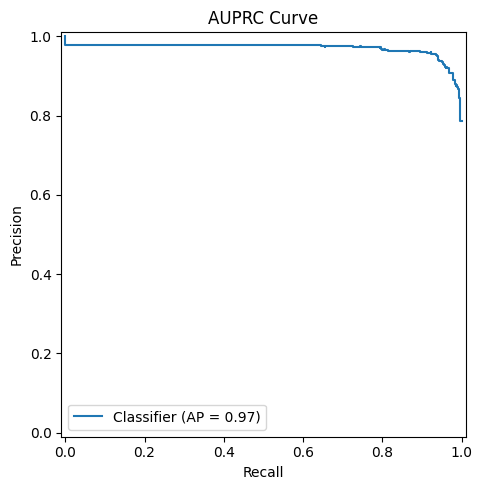

In [94]:
calc_metrics(final_model_knn, best_thr=best_thr_knn, model_name="knn_final")


In [95]:
calc_loss(final_model_knn)

Log Loss(Test): 0.7315882711182303
Log Loss(Train): 0.0049694980036909635
Focal Loss (Test Set): 0.0911


In [107]:
save_model(final_model_knn, "knn_bioactivity_model", "knn")


Model saved to saved_model/knn/


#### Ensembles

##### Voting 

In [108]:
import joblib

# Replace with your actual model name
model_name = "xgboost_bioactivity_model"  # or "random_forest_bioactivity_model", etc.
model_path = f"saved_model/xgboost/{model_name}.pkl"

# Load the model
final_model_xgb = joblib.load(model_path)


# Replace with your actual model name
model_name = "random_forest_bioactivity_model"  # or "random_forest_bioactivity_model", etc.
model_path = f"saved_model/rf/{model_name}.pkl"

# Load the model
final_model_rf = joblib.load(model_path)



# Replace with your actual model name
model_name = "lightgbm_bioactivity_model"  # or "random_forest_bioactivity_model", etc.
model_path = f"saved_model/lgbm/{model_name}.pkl"

# Load the model
final_model_lgbm = joblib.load(model_path)



# Replace with your actual model name
model_name = "catboost_bioactivity_model"  # or "random_forest_bioactivity_model", etc.
model_path = f"saved_model/catboost/{model_name}.pkl"

# Load the model
final_model_cat = joblib.load(model_path)



# Replace with your actual model name
model_name = "svm_bioactivity_model"  # or "random_forest_bioactivity_model", etc.
model_path = f"saved_model/svm/{model_name}.pkl"

# Load the model
final_model_svm = joblib.load(model_path)


# Replace with your actual model name
model_name = "extratree_bioactivity_model"  # or "random_forest_bioactivity_model", etc.
model_path = f"saved_model/extratree/{model_name}.pkl"

# Load the model
final_model_et = joblib.load(model_path)

In [ ]:
# ── VotingEnsemble 5-fold CV via OOF probability fusion ──────────────────────
# All 7 individual CVs used identical StratifiedKFold splits (same RANDOM_STATE).
# Combining their per-fold OOF probs is leakage-free and avoids retraining all
# base models 5× (which would take hours for SVM alone).
import warnings
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, average_precision_score,
    matthews_corrcoef, cohen_kappa_score, brier_score_loss,
    confusion_matrix, precision_recall_curve,
)

warnings.filterwarnings("ignore")

N_CV_SPLITS_VOTE = 5

# ── Soft-voting weights (equal by default — tune here if desired) ─────────────
VOTE_WEIGHTS = np.array([1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], dtype=float)
VOTE_NAMES   = ['xgb', 'lgbm', 'rf', 'cat', 'et', 'svm', 'knn']

print(f"Soft VotingEnsemble ({N_CV_SPLITS_VOTE}-Fold CV via OOF fusion)\n")
print(f"Base models : {VOTE_NAMES}")
print(f"Weights     : {VOTE_WEIGHTS.tolist()}\n")

# Stack OOF probs from all 7 individual models (N_train × 7) → weighted average
# Variable names produced by each model's CV cell:
#   oof_probs        (XGBoost)   oof_probs_lgbm   oof_probs_rf
#   oof_probs_cat    (CatBoost)  oof_probs_et     oof_probs_svm  oof_probs_knn
oof_stack_vote = np.column_stack([
    oof_probs,      oof_probs_lgbm, oof_probs_rf,
    oof_probs_cat,  oof_probs_et,   oof_probs_svm,  oof_probs_knn,
])
oof_probs_vote   = (oof_stack_vote @ VOTE_WEIGHTS) / VOTE_WEIGHTS.sum()
y_train_arr_vote = np.asarray(y_train)

# ── Reconstruct per-fold metrics using the same fold splits ───────────────────
cv_vote        = StratifiedKFold(n_splits=N_CV_SPLITS_VOTE, shuffle=True, random_state=RANDOM_STATE)
fold_data_vote = []

FOLD_COLS_VOTE = ['Acc', 'Bal.Acc', 'Prec', 'Rec', 'F1', 'AUC', 'AUPRC', 'MCC', 'Spec', 'Kappa', 'Brier']
hdr_line_vote  = f"{'Fold':>6}  " + "  ".join(f"{c:>8}" for c in FOLD_COLS_VOTE)
print(f"{hdr_line_vote}")
print("-" * len(hdr_line_vote))

for fold_idx, (_, val_idx) in enumerate(cv_vote.split(y_train_arr_vote, y_train_arr_vote)):
    yv  = y_train_arr_vote[val_idx]
    prb = oof_probs_vote[val_idx]
    prd = (prb >= 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(yv, prd).ravel()
    spec = tn / (tn + fp + 1e-12)
    npv  = tn / (tn + fn + 1e-12)
    m = {
        'Acc':     accuracy_score(yv, prd),
        'Bal.Acc': balanced_accuracy_score(yv, prd),
        'Prec':    precision_score(yv, prd, zero_division=0),
        'Rec':     recall_score(yv, prd, zero_division=0),
        'F1':      f1_score(yv, prd, zero_division=0),
        'AUC':     roc_auc_score(yv, prb),
        'AUPRC':   average_precision_score(yv, prb),
        'MCC':     matthews_corrcoef(yv, prd),
        'Spec':    spec,
        'Kappa':   cohen_kappa_score(yv, prd),
        'Brier':   brier_score_loss(yv, prb),
        'NPV':     npv,
    }
    fold_data_vote.append(m)
    row_str = "  ".join(f"{m[c]:>8.4f}" for c in FOLD_COLS_VOTE)
    print(f"{fold_idx + 1:>6}  {row_str}")

print("=" * len(hdr_line_vote))

# ── Per-metric summary ─────────────────────────────────────────────────────────
SUMMARY_MAP_VOTE = {
    'Accuracy':     'Acc',
    'Balanced Acc': 'Bal.Acc',
    'Precision':    'Prec',
    'Recall':       'Rec',
    'F1':           'F1',
    'ROC-AUC':      'AUC',
    'AUPRC':        'AUPRC',
    'MCC':          'MCC',
    'Sensitivity':  'Rec',
    'Specificity':  'Spec',
    'NPV':          'NPV',
    "Cohen's k":    'Kappa',
    'Brier':        'Brier',
}

def _ci95_vote(arr):
    se = np.std(arr, ddof=1) / np.sqrt(len(arr))
    return np.mean(arr) - 1.96 * se, np.mean(arr) + 1.96 * se

summary_rows_vote = {}
for label, col in SUMMARY_MAP_VOTE.items():
    vals = np.array([d[col] for d in fold_data_vote])
    lo, hi = _ci95_vote(vals)
    summary_rows_vote[label] = {
        'Mean +- Std': f"{np.mean(vals):.4f} +- {np.std(vals, ddof=1):.4f}",
        'Min':         f"{np.min(vals):.4f}",
        'Max':         f"{np.max(vals):.4f}",
        '95% CI':      f"[{lo:.4f}, {hi:.4f}]",
    }

summary_df_vote = pd.DataFrame(summary_rows_vote).T
summary_df_vote.index.name = 'Metric'
print(f"\n  Per-Metric Summary\n")
print(summary_df_vote.to_string())

# ── OOF threshold tuning ──────────────────────────────────────────────────────
oof_auc_vote  = roc_auc_score(y_train_arr_vote, oof_probs_vote)
oof_ap_vote   = average_precision_score(y_train_arr_vote, oof_probs_vote)
prec_c, rec_c, thr_c = precision_recall_curve(y_train_arr_vote, oof_probs_vote)
f1s_vote      = 2 * prec_c * rec_c / (prec_c + rec_c + 1e-8)
best_thr_vote = float(thr_c[np.argmax(f1s_vote[:-1])])

print(f"\nOOF ROC-AUC  : {oof_auc_vote:.4f}")
print(f"OOF AUPRC    : {oof_ap_vote:.4f}")
print(f"Optimal thr  : {best_thr_vote:.3f}  (OOF F1-max threshold)")

# ── Paper-ready summary ───────────────────────────────────────────────────────
PAPER_METRICS_VOTE = ['Accuracy', 'ROC-AUC', 'F1', 'MCC', 'AUPRC',
                      'Sensitivity', 'Specificity', "Cohen's k", 'Brier']
paper_df_vote = pd.DataFrame(
    {m: [summary_rows_vote[m]['Mean +- Std']] for m in PAPER_METRICS_VOTE},
    index=[f'VotingEnsemble ({N_CV_SPLITS_VOTE}-Fold CV)'],
).T
paper_df_vote.index.name = None
print(f"\n  Paper-Ready Summary\n")
print(paper_df_vote.to_string())


[I 2025-11-21 10:30:09,754] A new study created in memory with name: voting_optimization


VOTING CLASSIFIER OPTIMIZATION
Starting Voting Classifier optimization...


  0%|          | 0/31 [00:00<?, ?it/s]e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [10:30:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=900).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Best trial: 0. Best value: 0.857204:   3%|▎         | 1/31 [00:19<09:49, 19.63s/it]e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [10:30:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  

[I 2025-11-21 10:30:29,387] Trial 0 finished with value: 0.8572038525072097 and parameters: {'voting': 'hard'}. Best is trial 0 with value: 0.8572038525072097.


e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=900).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Best trial: 1. Best value: 0.960439:   6%|▋         | 2/31 [00:39<09:38, 19.95s/it]e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [10:30:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


...

[I 2025-11-21 10:39:57,413] Trial 28 finished with value: 0.9640927289525996 and parameters: {'voting': 'soft', 'weight_xgb': 1.3504518016948448, 'weight_lgbm': 1.8922196881882951, 'weight_rf': 1.9566561651881624, 'weight_cat': 1.460795200048445, 'weight_sf': 1.6591619083276954, 'weight_ext': 0.8874175814361605}. Best is trial 27 with value: 0.9644916986309041.


e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=900).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Best trial: 27. Best value: 0.964492:  97%|█████████▋| 30/31 [10:09<00:20, 20.93s/it]e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [10:40:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2025-11-21 10:40:19,032] Trial 29 finished with value: 0.8512018086625416 and parameters: {'voting': 'hard'}. Best is trial 27 with value: 0.9644916986309041.


e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=900).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Best trial: 27. Best value: 0.964492: 100%|██████████| 31/31 [10:30<00:00, 20.32s/it]

[I 2025-11-21 10:40:39,776] Trial 30 finished with value: 0.9625738443878266 and parameters: {'voting': 'soft', 'weight_xgb': 1.587742324549121, 'weight_lgbm': 1.38802921792744, 'weight_rf': 1.8017742260283671, 'weight_cat': 1.0809080624044292, 'weight_sf': 1.7891664701022467, 'weight_ext': 1.1761826289325492}. Best is trial 27 with value: 0.9644916986309041.

VOTING CLASSIFIER RESULTS
Best AUC: 0.9645

Best hyperparameters:
  voting: soft
  weight_xgb: 1.2596072216604863
  weight_lgbm: 1.8015243158548453
  weight_rf: 1.997909627607913
  weight_cat: 1.0766023113224443
  weight_sf: 1.4934874656915478
  weight_ext: 0.8358873684991758


In [ ]:
# ── Final VotingEnsemble: fresh base estimators trained on full training set ──
# X_train is globally StandardScaler-scaled (valid for all base models):
#   - tree models (XGB/LGBM/RF/CatBoost/ET): scale-invariant → no impact
#   - SVM/KNN: benefit from standardised features → consistent with global scaler
import warnings
import numpy as np
import pandas as pd
from sklearn.ensemble import VotingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score,
    recall_score, f1_score, roc_auc_score, average_precision_score,
    matthews_corrcoef, cohen_kappa_score, brier_score_loss,
    confusion_matrix, classification_report,
)

warnings.filterwarnings("ignore")

y_train_full_vote = np.asarray(y_train)

# Full training pool imbalance ratio (for scale_pos_weight-based models)
final_imbalance_ratio_vote = (y_train_full_vote == 0).sum() / ((y_train_full_vote == 1).sum() + 1e-8)
print(f"Final training pool imbalance ratio: {final_imbalance_ratio_vote:.2f}:1\n")

# ── Build estimators using fixed params from each model's CV cell ─────────────
# XGBoost: remove early_stopping_rounds; use avg best_iter from CV folds
_xgb_p = {k: v for k, v in xgb_params.items() if k != 'early_stopping_rounds'}
_xgb_p.update({'n_estimators': best_n_trees, 'scale_pos_weight': final_imbalance_ratio_vote})

# LightGBM: use avg best_iter from CV folds; update scale_pos_weight
_lgbm_p = dict(lgbm_params)
_lgbm_p.update({'n_estimators': best_n_trees_lgbm, 'scale_pos_weight': final_imbalance_ratio_vote})

# CatBoost: use avg best_iter from CV folds; update scale_pos_weight
_cat_p = dict(cat_params)
_cat_p.update({'iterations': best_n_trees_cat, 'scale_pos_weight': final_imbalance_ratio_vote})

vote_estimators_final = [
    ('xgb',  XGBClassifier(**_xgb_p)),
    ('lgbm', LGBMClassifier(**_lgbm_p)),
    ('rf',   RandomForestClassifier(**rf_params)),
    ('cat',  CatBoostClassifier(**_cat_p)),
    ('et',   ExtraTreesClassifier(**et_params)),
    ('svm',  SVC(**svm_params)),
    ('knn',  KNeighborsClassifier(**knn_params)),
]

voting_model = VotingClassifier(
    estimators=vote_estimators_final,
    voting='soft',
    weights=VOTE_WEIGHTS.tolist(),
    n_jobs=1,
)
voting_model.fit(X_train, y_train_full_vote)
print(f"Final VotingEnsemble trained  |  threshold = {best_thr_vote:.3f}\n")

y_prob_vote = voting_model.predict_proba(X_test)[:, 1]
y_true_vote = np.asarray(y_test)

def _eval_vote(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return y_pred, {
        'Accuracy':     accuracy_score(y_true, y_pred),
        'Balanced Acc': balanced_accuracy_score(y_true, y_pred),
        'Precision':    precision_score(y_true, y_pred, zero_division=0),
        'Recall':       recall_score(y_true, y_pred, zero_division=0),
        'F1':           f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC':      roc_auc_score(y_true, y_prob),
        'AUPRC':        average_precision_score(y_true, y_prob),
        'MCC':          matthews_corrcoef(y_true, y_pred),
        'Specificity':  tn / (tn + fp + 1e-12),
        'NPV':          tn / (tn + fn + 1e-12),
        "Cohen's k":    cohen_kappa_score(y_true, y_pred),
        'Brier':        brier_score_loss(y_true, y_prob),
    }

y_pred_default_vote, m_default_vote = _eval_vote(y_true_vote, y_prob_vote, 0.50)
y_pred_tuned_vote,   m_tuned_vote   = _eval_vote(y_true_vote, y_prob_vote, best_thr_vote)

cmp_df_vote = pd.DataFrame({
    #'thr=0.500 (default)':                    m_default_vote,
    f'thr={best_thr_vote:.3f} (OOF-tuned)': m_tuned_vote,
})
print("  Test Set Comparison\n")
print(cmp_df_vote.to_string(float_format=lambda x: f"{x:.4f}"))

print(f"\n  Classification Report  (threshold = {best_thr_vote:.3f})\n")
print(classification_report(y_true_vote, y_pred_tuned_vote, target_names=['Inactive', 'Active']))


e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [10:46:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=900).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


classification_report
              precision    recall  f1-score   support

           0       0.91      0.74      0.82       180
           1       0.94      0.98      0.96       772

    accuracy                           0.94       952
   macro avg       0.93      0.86      0.89       952
weighted avg       0.94      0.94      0.94       952



e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.9380
Balanced Acc.: 0.8638
Cohen's Kappa: 0.7826
Precision: 0.9429
Recall: 0.9832
F1 Score: 0.9626
ROC-AUC: 0.9641
AUPRC: 0.9886
MCC: 0.7885
NPV: 0.9116
Specificity: 0.7444
Sensitivity: 0.9832
Informedness: 0.7276
DOR: 170.0769
Brier Score: 0.0518
********************
Confusion Matrix:


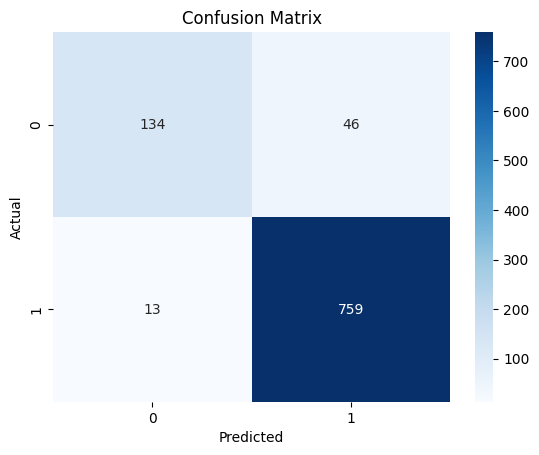

ROC Curve:


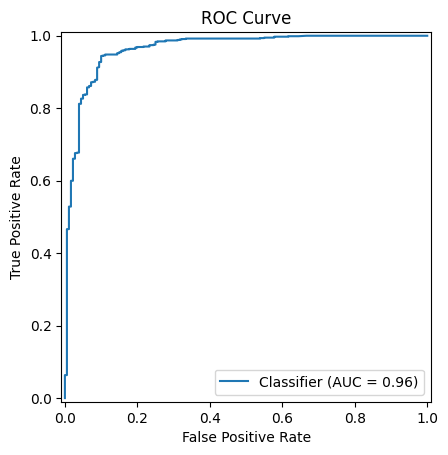

AUPRC Curve:


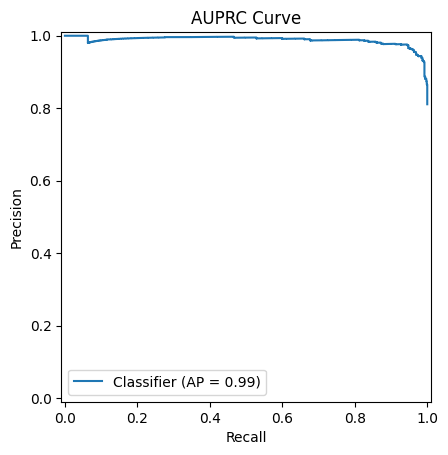

In [ ]:
calc_metrics(voting_model, best_thr=best_thr_vote, model_name="voting_final")


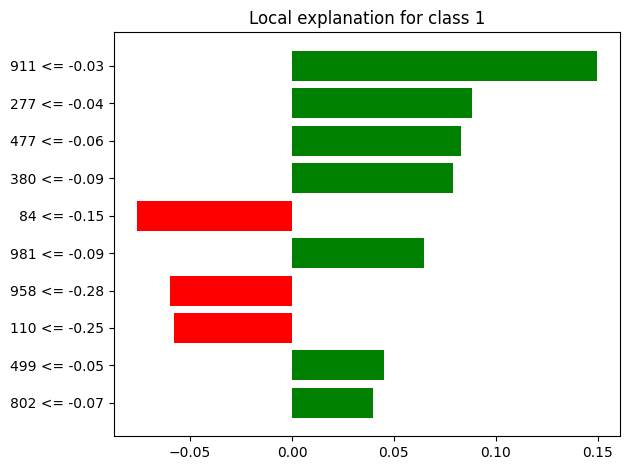


Feature contributions:
[('911 <= -0.03', 0.1496308227435044), ('277 <= -0.04', 0.08820697631825977), ('477 <= -0.06', 0.08290040697853725), ('380 <= -0.09', 0.07897755564758215), ('84 <= -0.15', -0.07602296436455713), ('981 <= -0.09', 0.06474482480789492), ('958 <= -0.28', -0.0600420255951942), ('110 <= -0.25', -0.05765289937634996), ('499 <= -0.05', 0.04509903934089284), ('802 <= -0.07', 0.03953451151167671)]

Explanation as dict:
{1: [(np.int64(911), np.float64(0.1496308227435044)), (np.int64(277), np.float64(0.08820697631825977)), (np.int64(477), np.float64(0.08290040697853725)), (np.int64(380), np.float64(0.07897755564758215)), (np.int64(84), np.float64(-0.07602296436455713)), (np.int64(981), np.float64(0.06474482480789492)), (np.int64(958), np.float64(-0.0600420255951942)), (np.int64(110), np.float64(-0.05765289937634996)), (np.int64(499), np.float64(0.04509903934089284)), (np.int64(802), np.float64(0.03953451151167671))]}


In [ ]:
lime_plot(voting_model)

In [ ]:
save_model(voting_model, "voting_bioactivity_model")


Model and metadata saved to saved_model/ml_models/


<!-- ##### Stacking -->

In [ ]:
# import joblib
# model_ = joblib.load("saved_model/ml_models/lightgbm_bioactivity_model.pkl")

In [74]:
import optuna
from optuna.samplers import TPESampler
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier, RidgeClassifierCV
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score
import numpy as np
import os

# ============================================================================
# HYBRID APPROACH: Speed + Accuracy Balance
# ============================================================================

def objective_stacking_balanced(trial):
    """
    BALANCED VERSION: Good speed (5-8 min/trial) + High accuracy
    
    Speed optimizations:
    - Fixed CV=3 (vs 3-5)
    - Moderate n_jobs=2
    - Reduced but comprehensive search space
    
    Accuracy maintained:
    - All 5 meta-learner types (LR, XGB, LGBM, Cat, SVM)
    - Key hyperparameters still tuned
    - Passthrough still optimized
    """
    
    base_estimators = [
        ('xgb', final_model_xgb),
        ('lgbm', final_model_lgbm),
        ('catboost', final_model_cat),
        ('rf', final_model_rf),
        ('sf', final_model_svm),
        ('ext', final_model_et)
    ]
    
    # All meta-learners included for accuracy
    meta_learner_type = trial.suggest_categorical('meta_learner', ['lr', 'ridge', 'ridge_cv'])
    
    if meta_learner_type == 'lr':
        # Simplified but still effective
        meta_penalty = trial.suggest_categorical('meta_penalty', ['l2', 'l1', 'elasticnet'])
         
        meta_solver = trial.suggest_categorical('meta_solver', ['lbfgs', 'saga'])
        
        if meta_penalty == 'l2' and meta_solver not in ['lbfgs', 'saga']:
            raise optuna.TrialPruned()
        if meta_penalty in ['l1', 'elasticnet'] and meta_solver != 'saga':
            raise optuna.TrialPruned()
        
        params = {
            'C': trial.suggest_float('meta_C', 0.01, 10, log=True),
            'class_weight': trial.suggest_categorical('meta_class_weight', ['balanced']),
            'random_state': 42,
            'max_iter': 1000,  # Fixed for speed
            'solver': meta_solver,
            'penalty': meta_penalty,
            'tol': 1e-4 # Fixed for speed
        }
        if meta_penalty == 'elasticnet':
            params['l1_ratio'] = trial.suggest_float('meta_l1_ratio', 0.0, 1.0)
        
        meta_learner = LogisticRegression(**params)
    
    elif meta_learner_type == 'ridge':
        meta_learner = RidgeClassifier(
            alpha=trial.suggest_float('meta_alpha', 1e-3, 10.0, log=True),
            class_weight=trial.suggest_categorical('meta_class_weight', ['balanced']),
            max_iter=1000,
            tol=1e-4
        )
    else:
        meta_learner = RidgeClassifierCV(
            alphas=np.logspace(-3, 3, 10),
            class_weight=trial.suggest_categorical('meta_class_weight', ['balanced']),
            cv=3
        )   
    
    
    # Moderate n_jobs=2 (faster than 1, safer than -1)
    model = StackingClassifier(
        estimators=base_estimators,
        final_estimator=meta_learner,
        passthrough=trial.suggest_categorical('passthrough', [True, False])  # Keep for accuracy
    )
    
    try:
        model.fit(X_train, y_train)
        # Only call predict_proba if supported
        if hasattr(model, "predict_proba"):
            preds_proba = model.predict_proba(X_val)[:, 1]
            auc = roc_auc_score(y_val, preds_proba)
        else:
            preds = model.predict(X_val)
            auc = roc_auc_score(y_val, preds)
        return auc
    except Exception as e:
        print(f"Trial failed: {e}")
        return 0.0



# ============================================================================
# EXECUTION: Choose Your Strategy
# ============================================================================

os.environ['OPTUNA_DISABLE_FORK'] = '1'

print("\n" + "="*80)
print("STACKING OPTIMIZATION: SPEED + ACCURACY BALANCED")
print("="*80)

# ============================================================================
# OPTION 1: BALANCED (Recommended - Good for most cases)
# Time: ~5-8 min/trial, 30 trials = 2.5-4 hours
# Accuracy: High (all meta-learners, key params tuned)
# ============================================================================

print("\n[OPTION 1: BALANCED APPROACH]")
print("Expected accuracy: High (comprehensive search)")

study_balanced = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3)
)

study_balanced.optimize(objective_stacking_balanced, n_trials=31, show_progress_bar=True)

print(f"\n✓ Best AUC: {study_balanced.best_value:.4f}")
print(f"Best meta-learner: {study_balanced.best_params['meta_learner']}")


# ============================================================================
# RESULTS AND FINAL MODEL
# ============================================================================

study_final = study_balanced  # or study_stage2 if using two-stage

print("\n" + "="*80)
print("OPTIMIZATION RESULTS")
print("="*80)
print(f"Best Validation AUC: {1 - study_final.best_value:.4f}")
print(f"\nBest Parameters:")
for key, value in study_final.best_params.items():
    print(f"  {key}: {value}")

[I 2025-11-21 22:52:22,454] A new study created in memory with name: no-name-9a020033-3e35-4fca-9a63-611ec73c81fc



STACKING OPTIMIZATION: SPEED + ACCURACY BALANCED

[OPTION 1: BALANCED APPROACH]
Expected accuracy: High (comprehensive search)


  0%|          | 0/31 [00:00<?, ?it/s]e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:52:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=900).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:52:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:52:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, 

[I 2025-11-21 22:54:31,470] Trial 0 finished with value: 0.8610920570036678 and parameters: {'meta_learner': 'ridge', 'meta_alpha': 0.24810409748678125, 'meta_class_weight': 'balanced', 'passthrough': True}. Best is trial 0 with value: 0.8610920570036678.


e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=900).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:54:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:54:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:54:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivi

...

[I 2025-11-21 23:52:57,522] Trial 28 finished with value: 0.8815480023518214 and parameters: {'meta_learner': 'ridge_cv', 'meta_class_weight': 'balanced', 'passthrough': False}. Best is trial 25 with value: 0.9640087353361145.


e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=900).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [23:53:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [23:53:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [23:53:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivi

[I 2025-11-21 23:55:10,244] Trial 29 finished with value: 0.8715632611921493 and parameters: {'meta_learner': 'ridge', 'meta_alpha': 0.0016462494656141725, 'meta_class_weight': 'balanced', 'passthrough': False}. Best is trial 25 with value: 0.9640087353361145.


e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [23:55:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=900).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [23:55:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [23:55:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivi

[I 2025-11-21 23:57:23,980] Trial 30 finished with value: 0.8675245681328219 and parameters: {'meta_learner': 'ridge', 'meta_alpha': 9.777198713756135, 'meta_class_weight': 'balanced', 'passthrough': False}. Best is trial 25 with value: 0.9640087353361145.

✓ Best AUC: 0.9640
Best meta-learner: lr

OPTIMIZATION RESULTS
Best Validation AUC: 0.0360

Best Parameters:
  meta_learner: lr
  meta_penalty: l2
  meta_solver: lbfgs
  meta_C: 0.13106062699357715
  meta_class_weight: balanced
  passthrough: False


In [75]:
for key, value in study_final.best_params.items():
    print(f"  {key}: {value}")

  meta_learner: lr
  meta_penalty: l2
  meta_solver: lbfgs
  meta_C: 0.13106062699357715
  meta_class_weight: balanced
  passthrough: False


In [76]:
import pickle

# Save to pickle (after optimization)
with open("study_stacking.pkl", "wb") as f:
    pickle.dump(study_final, f)
print("Study saved to study_stacking.pkl")



Study saved to study_stacking.pkl


In [ ]:
# study_final

e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [02:49:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=900).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [02:50:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivity\.venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [02:50:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
e:\ML\BioActivi


Final Stacking Model Performance:
  Accuracy: 0.9265
  ROC-AUC: 0.9573

Confusion Matrix:
[[156  24]
 [ 46 726]]

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.87      0.82       180
           1       0.97      0.94      0.95       772

    accuracy                           0.93       952
   macro avg       0.87      0.90      0.89       952
weighted avg       0.93      0.93      0.93       952


EVALUATING FINAL STACKING MODEL


e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
e:\ML\BioActivity\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.9265
Balanced Acc.: 0.9035
Cohen's Kappa: 0.7710
Precision: 0.9680
Recall: 0.9404
F1 Score: 0.9540
ROC-AUC: 0.9573
AUPRC: 0.9882
MCC: 0.7730
NPV: 0.7723
Specificity: 0.8667
Sensitivity: 0.9404
Informedness: 0.8071
DOR: 102.5870
Brier Score: 0.0578
********************
Confusion Matrix:


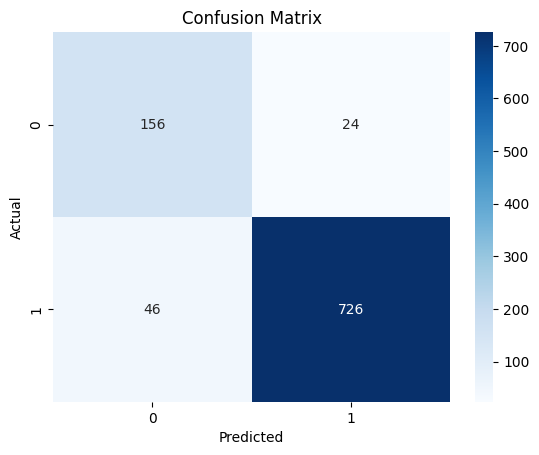

ROC Curve:


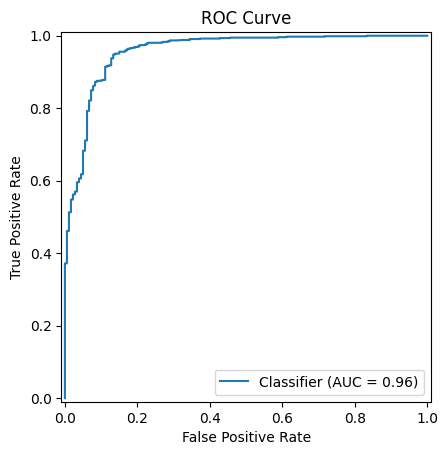

AUPRC Curve:


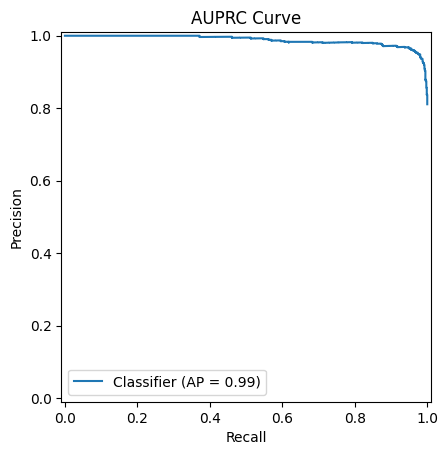

Model and metadata saved to saved_model/ml_models/
Final Stacking model saved as 'stacking_bioactivity_model.pkl'


In [83]:
best_params = study_final.best_params
scale_pos_weight_full = (y_train_full == 0).sum() / (y_train_full == 1).sum()
final_model_stacking = StackingClassifier(
    estimators=[
        ('xgb', final_model_xgb),
        ('lgbm', final_model_lgbm),
        ('catboost', final_model_cat),
        ('rf', final_model_rf),
        ('sf', final_model_svm),
        ('ext', final_model_et)
    ],

    final_estimator = LogisticRegression(
        C=best_params['meta_C'],
        class_weight='balanced',
        random_state=42,
        max_iter=2000,
        solver=best_params['meta_solver'],
        penalty=best_params['meta_penalty'],
        tol=1e-4
    ) ,
    stack_method='predict_proba',
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    passthrough=True
)

final_model_stacking.fit(X_train_full, y_train_full)
y_test_pred = final_model_stacking.predict(X_test)
y_test_pred_proba = final_model_stacking.predict_proba(X_test)[:, 1]
final_auc = roc_auc_score(y_test, y_test_pred_proba)
print(f"\nFinal Stacking Model Performance:")
print(f"  Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"  ROC-AUC: {final_auc:.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))
print(f"\nClassification Report:")
print(classification_report(y_test, y_test_pred))
print("\n" + "="*80)
print("EVALUATING FINAL STACKING MODEL")
calc_metrics(final_model_stacking)
save_model(final_model_stacking, best_params, "stacking_bioactivity_model")
print("Final Stacking model saved as 'stacking_bioactivity_model.pkl'")

In [79]:
# ============================================================================
# 3. BAGGING CLASSIFIER
# ============================================================================

print("\n\n" + "="*70)
print("BAGGING CLASSIFIER OPTIMIZATION")
print("="*70)

def objective_bagging(trial):
    """
    Bagging Classifier with optimized base estimator
    """
    
    # Base estimator choice
    base_estimator_type = trial.suggest_categorical('base_estimator', ['dt', 'svm', 'knn'])
    
    if base_estimator_type == 'dt':
        base_estimator = DecisionTreeClassifier(
            max_depth=trial.suggest_int('dt_max_depth', 3, 20),
            min_samples_split=trial.suggest_int('dt_min_samples_split', 2, 10),
            min_samples_leaf=trial.suggest_int('dt_min_samples_leaf', 1, 5),
            class_weight='balanced',
            random_state=42
        )
    elif base_estimator_type == 'svm':
        base_estimator = SVC(
            C=trial.suggest_float('svm_C', 0.1, 10, log=True),
            kernel=trial.suggest_categorical('svm_kernel', ['rbf', 'linear']),
            class_weight='balanced',
            probability=True,
            random_state=42
        )
    else:  # knn
        base_estimator = KNeighborsClassifier(
            n_neighbors=trial.suggest_int('knn_n_neighbors', 3, 20),
            weights=trial.suggest_categorical('knn_weights', ['uniform', 'distance']),
            metric='minkowski'
        )
    
    # Bagging parameters
    param = {
        'estimator': base_estimator,
        'n_estimators': trial.suggest_int('n_estimators', 10, 100),
        'max_samples': trial.suggest_float('max_samples', 0.5, 1.0),
        'max_features': trial.suggest_float('max_features', 0.5, 1.0),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'bootstrap_features': trial.suggest_categorical('bootstrap_features', [True, False]),
        'random_state': 42,
    }
    
    model = BaggingClassifier(**param)
    
    try:
        # Fit the model
        model.fit(X_train, y_train)
        
        # Get predictions
        preds_proba = model.predict_proba(X_val)[:, 1]
        
        # Calculate AUC
        auc = roc_auc_score(y_val, preds_proba)
        
        return auc
    
    except Exception as e:
        print(f"Trial failed with error: {e}")
        return 0  # Return worst score on failure

study_bagging = optuna.create_study(
    direction="maximize",
    study_name="bagging_optimization",
    sampler=optuna.samplers.TPESampler(seed=42)
)

print("Starting Bagging Classifier optimization...")
study_bagging.optimize(objective_bagging, n_trials=30, show_progress_bar=True)

print("\n" + "="*70)
print("BAGGING CLASSIFIER RESULTS")
print("="*70)
print(f"Best AUC: {1 - study_bagging.best_value:.4f}")
print(f"\nBest hyperparameters:")
for key, value in study_bagging.best_params.items():
    print(f"  {key}: {value}")




[I 2025-11-22 00:15:46,703] A new study created in memory with name: bagging_optimization




BAGGING CLASSIFIER OPTIMIZATION
Starting Bagging Classifier optimization...


Best trial: 0. Best value: 0.948799:   3%|▎         | 1/30 [01:36<46:26, 96.10s/it]

[I 2025-11-22 00:17:22,799] Trial 0 finished with value: 0.9487988912842624 and parameters: {'base_estimator': 'svm', 'svm_C': 1.5751320499779735, 'svm_kernel': 'rbf', 'n_estimators': 15, 'max_samples': 0.9330880728874675, 'max_features': 0.8005575058716043, 'bootstrap': True, 'bootstrap_features': True}. Best is trial 0 with value: 0.9487988912842624.


Best trial: 0. Best value: 0.948799:   7%|▋         | 2/30 [01:38<19:07, 40.97s/it]

...

[I 2025-11-22 00:25:41,297] Trial 27 finished with value: 0.9517666657334043 and parameters: {'base_estimator': 'dt', 'dt_max_depth': 20, 'dt_min_samples_split': 3, 'dt_min_samples_leaf': 4, 'n_estimators': 72, 'max_samples': 0.9244915385900426, 'max_features': 0.801611390106866, 'bootstrap': True, 'bootstrap_features': True}. Best is trial 22 with value: 0.9575412268667581.


Best trial: 22. Best value: 0.957541:  97%|█████████▋| 29/30 [25:47<04:54, 294.93s/it]

[I 2025-11-22 00:41:33,838] Trial 28 finished with value: 0.9242167595262759 and parameters: {'base_estimator': 'svm', 'svm_C': 0.18189366309739655, 'svm_kernel': 'rbf', 'n_estimators': 85, 'max_samples': 0.9732709746222247, 'max_features': 0.8837994836600225, 'bootstrap': True, 'bootstrap_features': True}. Best is trial 22 with value: 0.9575412268667581.


Best trial: 22. Best value: 0.957541: 100%|██████████| 30/30 [26:01<00:00, 52.07s/it] 

[I 2025-11-22 00:41:48,660] Trial 29 finished with value: 0.9159853851107316 and parameters: {'base_estimator': 'knn', 'knn_n_neighbors': 19, 'knn_weights': 'distance', 'n_estimators': 97, 'max_samples': 0.9065041611766789, 'max_features': 0.811933154502673, 'bootstrap': True, 'bootstrap_features': True}. Best is trial 22 with value: 0.9575412268667581.

BAGGING CLASSIFIER RESULTS
Best AUC: 0.0425

Best hyperparameters:
  base_estimator: dt
  dt_max_depth: 18
  dt_min_samples_split: 5
  dt_min_samples_leaf: 2
  n_estimators: 88
  max_samples: 0.8335260630715573
  max_features: 0.9272566041814421
  bootstrap: True
  bootstrap_features: True


In [80]:
best_params_bagging = study_bagging.best_params
final_model_bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=best_params_bagging['dt_max_depth'],
        min_samples_split=best_params_bagging['dt_min_samples_split'],
        min_samples_leaf=best_params_bagging['dt_min_samples_leaf'],
        class_weight='balanced',
        random_state=42
    ),
    n_estimators=best_params_bagging['n_estimators'],
    max_samples=best_params_bagging['max_samples'],
    max_features=best_params_bagging['max_features'],
    bootstrap=best_params_bagging['bootstrap'],
    bootstrap_features=best_params_bagging['bootstrap_features'],
    random_state=42,
)

final_model_bagging.fit(X_train_full, y_train_full)
y_test_pred_bagging = final_model_bagging.predict(X_test)
y_test_pred_proba_bagging = final_model_bagging.predict_proba(X_test)[:, 1]
final_auc_bagging = roc_auc_score(y_test, y_test_pred_proba_bagging)
print(f"\nFinal Bagging Model Performance:")
print(f"AUC: {final_auc_bagging:.4f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_bagging))
print(f"\nClassification Report:")
print(classification_report(y_test, y_test_pred_bagging))



Final Bagging Model Performance:
AUC: 0.9607

Confusion Matrix:
[[143  37]
 [ 30 742]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       180
           1       0.95      0.96      0.96       772

    accuracy                           0.93       952
   macro avg       0.89      0.88      0.88       952
weighted avg       0.93      0.93      0.93       952



Accuracy: 0.9296
Balanced Acc.: 0.8778
Cohen's Kappa: 0.7670
Precision: 0.9525
Recall: 0.9611
F1 Score: 0.9568
ROC-AUC: 0.9607
AUPRC: 0.9882
MCC: 0.7672
NPV: 0.8266
Specificity: 0.7944
Sensitivity: 0.9611
Informedness: 0.7556
DOR: 95.5910
Brier Score: 0.0558
********************
Confusion Matrix:


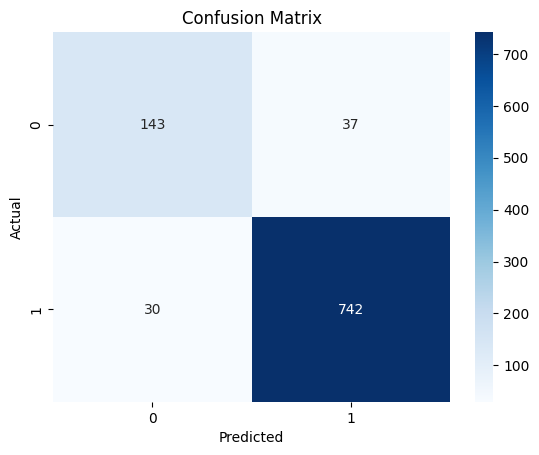

ROC Curve:


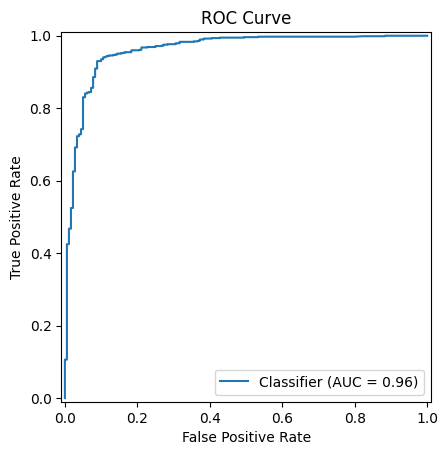

AUPRC Curve:


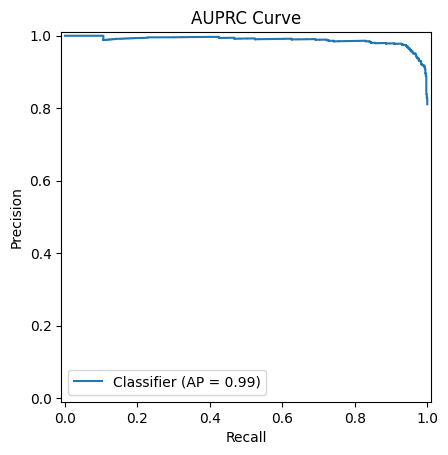

In [81]:
calc_metrics(final_model_bagging)